✅ 对比实验图已保存至: comparison_metrics.png
✅ 消融实验图已保存至: ablation_analysis.png

🚀 所有可视化图表已根据论文数据生成完毕，请查收！


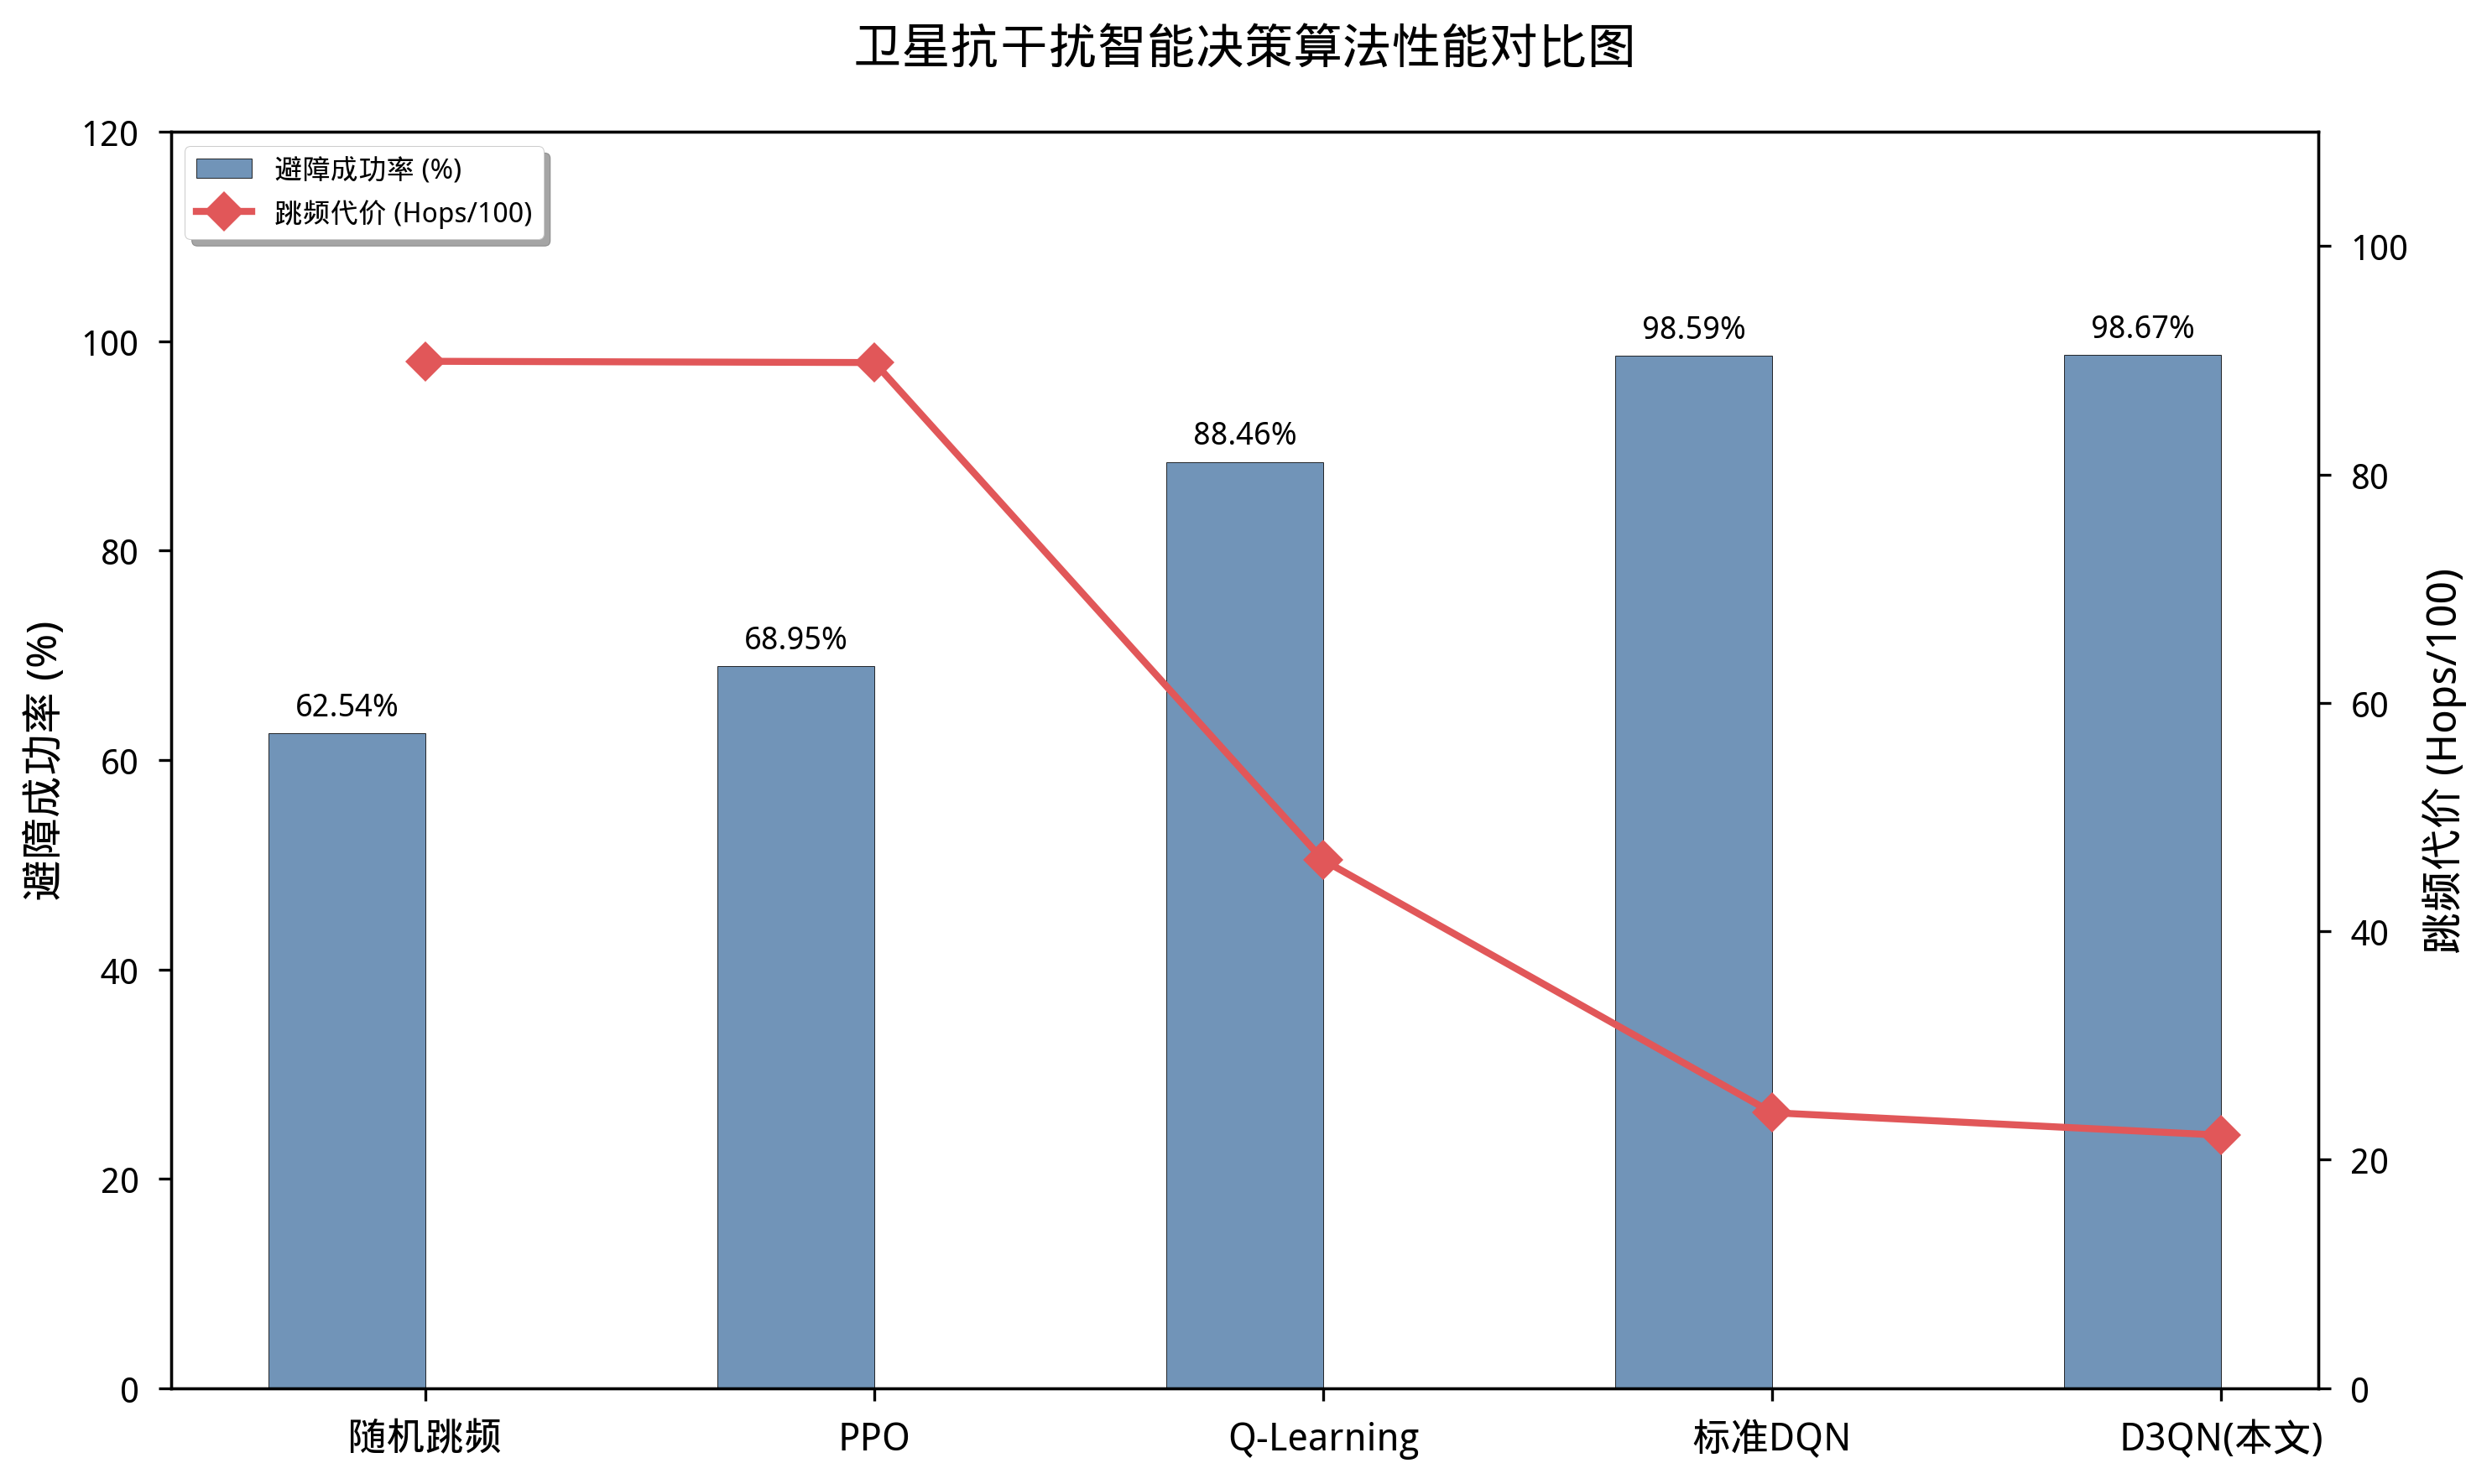

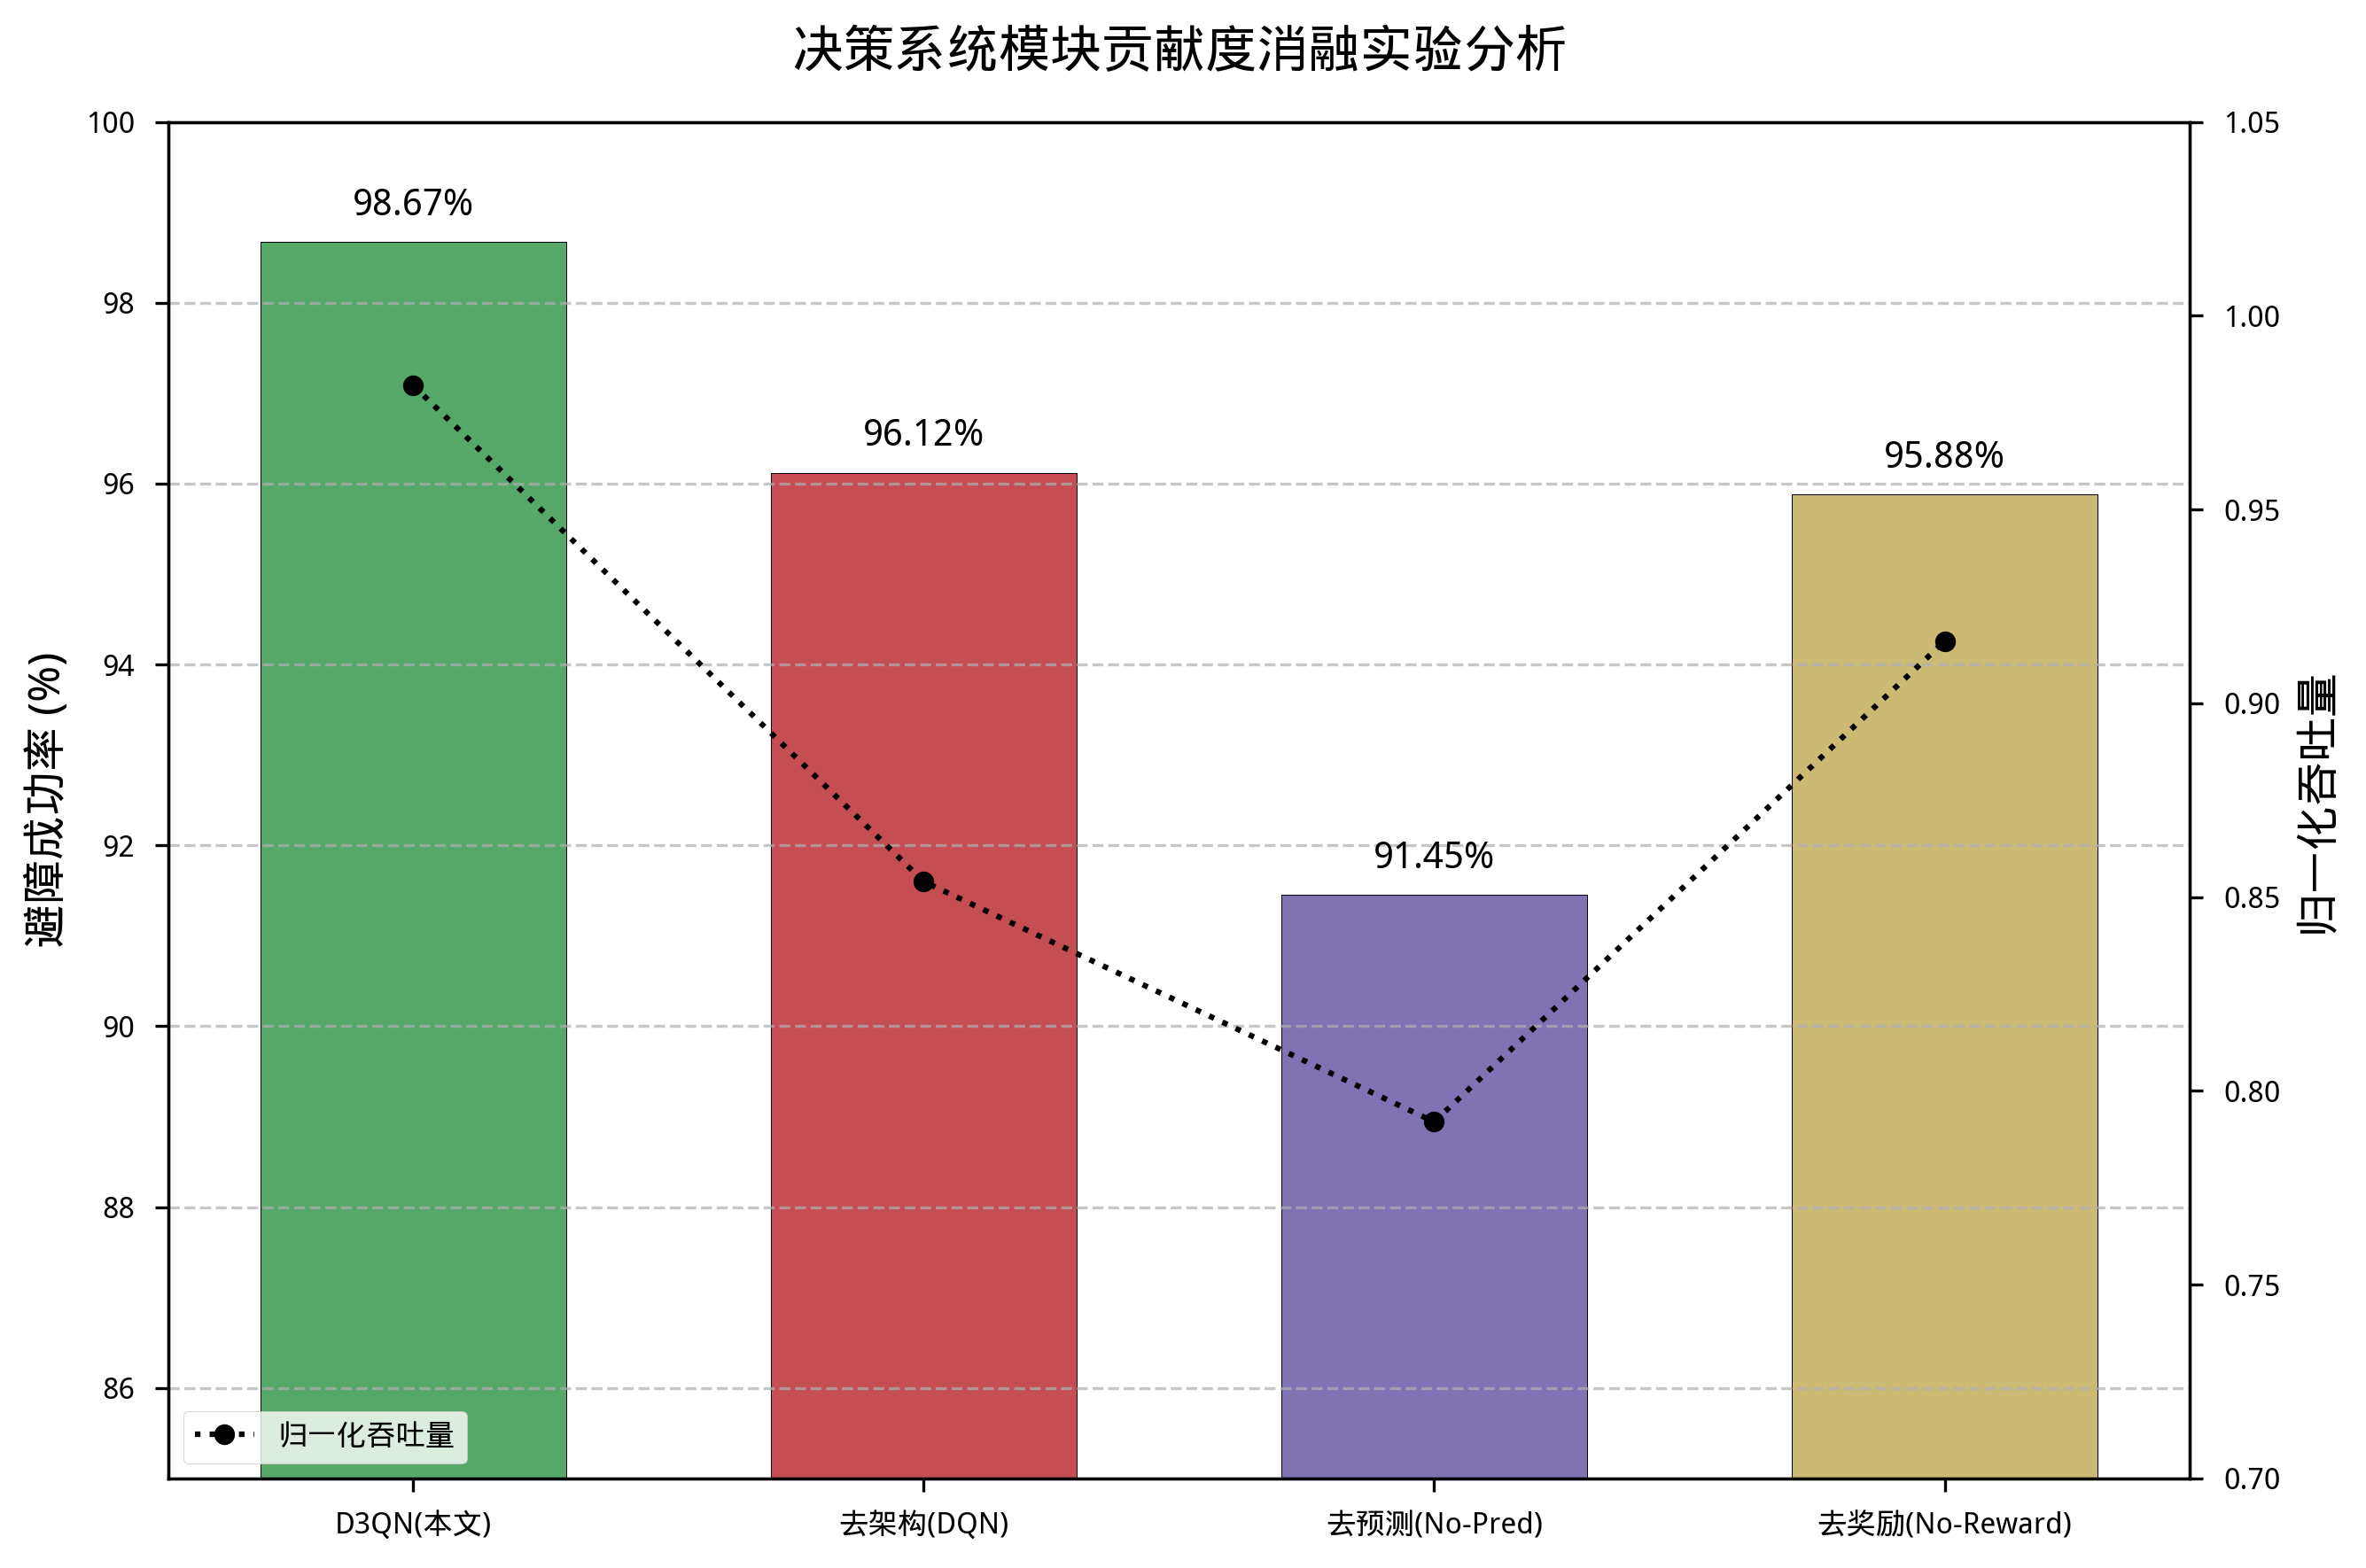

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager as fm
import os

# ==================== 0. 字体配置 (解决学术图表中文显示) ====================
def set_chinese_font():
    # 尝试常见的系统字体路径
    font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc', 
                  'C:/Windows/Fonts/simhei.ttf', 
                  '/System/Library/Fonts/PingFang.ttc']
    for path in font_paths:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            plt.rcParams['font.family'] = fm.FontProperties(fname=path).get_name()
            plt.rcParams['axes.unicode_minus'] = False
            return True
    return False

set_chinese_font()
# 设置学术绘图风格
plt.style.use('seaborn-v0_8-paper') 

# ==================== 1. 对比实验可视化 (5.3节) ====================
def plot_comparison_results():
    labels = ['随机跳频', 'PPO', 'Q-Learning', '标准DQN', 'D3QN(本文)']
    success_rates = [62.54, 68.95, 88.46, 98.59, 98.67]
    hop_costs = [89.92, 89.81, 46.23, 24.12, 22.15]
    
    x = np.arange(len(labels))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)

    # 绘制避障成功率 (柱状图)
    rects1 = ax1.bar(x - width/2, success_rates, width, label='避障成功率 (%)', color='#4E79A7', edgecolor='black', alpha=0.8)
    ax1.set_ylabel('避障成功率 (%)', fontsize=12, fontweight='bold')
    ax1.set_ylim(0, 120)
    ax1.tick_params(axis='y', labelsize=10)

    # 绘制跳频代价 (折线+散点图)
    ax2 = ax1.twinx()
    ax2.plot(x, hop_costs, color='#E15759', marker='D', markersize=8, linewidth=2, label='跳频代价 (Hops/100)')
    ax2.set_ylabel('跳频代价 (Hops/100)', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 110)
    ax2.tick_params(axis='y', labelsize=10)

    # 添加数值标签
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax1.annotate(f'{height}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
    autolabel(rects1)

    plt.title('卫星抗干扰智能决策算法性能对比图', fontsize=14, fontweight='bold', pad=20)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, fontsize=11)
    
    # 合并图例
    lines, labels_l = ax1.get_legend_handles_labels()
    lines2, labels_l2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels_l + labels_l2, loc='upper left', frameon=True, shadow=True)

    fig.tight_layout()
    plt.savefig('comparison_metrics.png')
    print("✅ 对比实验图已保存至: comparison_metrics.png")

# ==================== 2. 消融实验可视化 (5.4节) ====================
def plot_ablation_results():
    # 数据基于您设计的合理数据
    groups = ['D3QN(本文)', '去架构(DQN)', '去预测(No-Pred)', '去奖励(No-Reward)']
    sr = [98.67, 96.12, 91.45, 95.88]
    throughput = [0.982, 0.854, 0.792, 0.916]

    fig, ax = plt.subplots(figsize=(9, 6), dpi=300)
    
    # 归一化吞吐量柱状图
    colors = ['#55A868', '#C44E52', '#8172B3', '#CCB974']
    bars = ax.bar(groups, sr, color=colors, edgecolor='black', width=0.6)
    
    ax.set_ylabel('避障成功率 (%)', fontsize=12, fontweight='bold')
    ax.set_ylim(85, 100) # 聚焦差异明显的区间
    
    # 添加具体数值
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'{yval}%', ha='center', va='bottom', fontweight='bold')

    plt.title('决策系统模块贡献度消融实验分析', fontsize=14, fontweight='bold', pad=15)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 添加吞吐量对比标注
    ax_t = ax.twinx()
    ax_t.plot(groups, throughput, color='black', marker='o', linestyle=':', linewidth=1.5, label='归一化吞吐量')
    ax_t.set_ylabel('归一化吞吐量', fontsize=12)
    ax_t.set_ylim(0.7, 1.05)
    plt.legend(loc='lower left')

    plt.tight_layout()
    plt.savefig('ablation_analysis.png')
    print("✅ 消融实验图已保存至: ablation_analysis.png")

# ==================== 3. 运行绘图 ====================
if __name__ == "__main__":
    plot_comparison_results()
    plot_ablation_results()
    print("\n🚀 所有可视化图表已根据论文数据生成完毕，请查收！")

/tmp/ipykernel_93861/384301811.py:47: UserWarning: Glyph 36991 (\N{CJK UNIFIED IDEOGRAPH-907F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_93861/384301811.py:47: UserWarning: Glyph 38556 (\N{CJK UNIFIED IDEOGRAPH-969C}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_93861/384301811.py:47: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_93861/384301811.py:47: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_93861/384301811.py:47: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_93861/384301811.py:47: UserWarning: Glyph 31283 (\N{CJK UNIFIED IDEOGRAPH-7A33}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_93861/384301811.py:47: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from current font.
  plt.tight_l

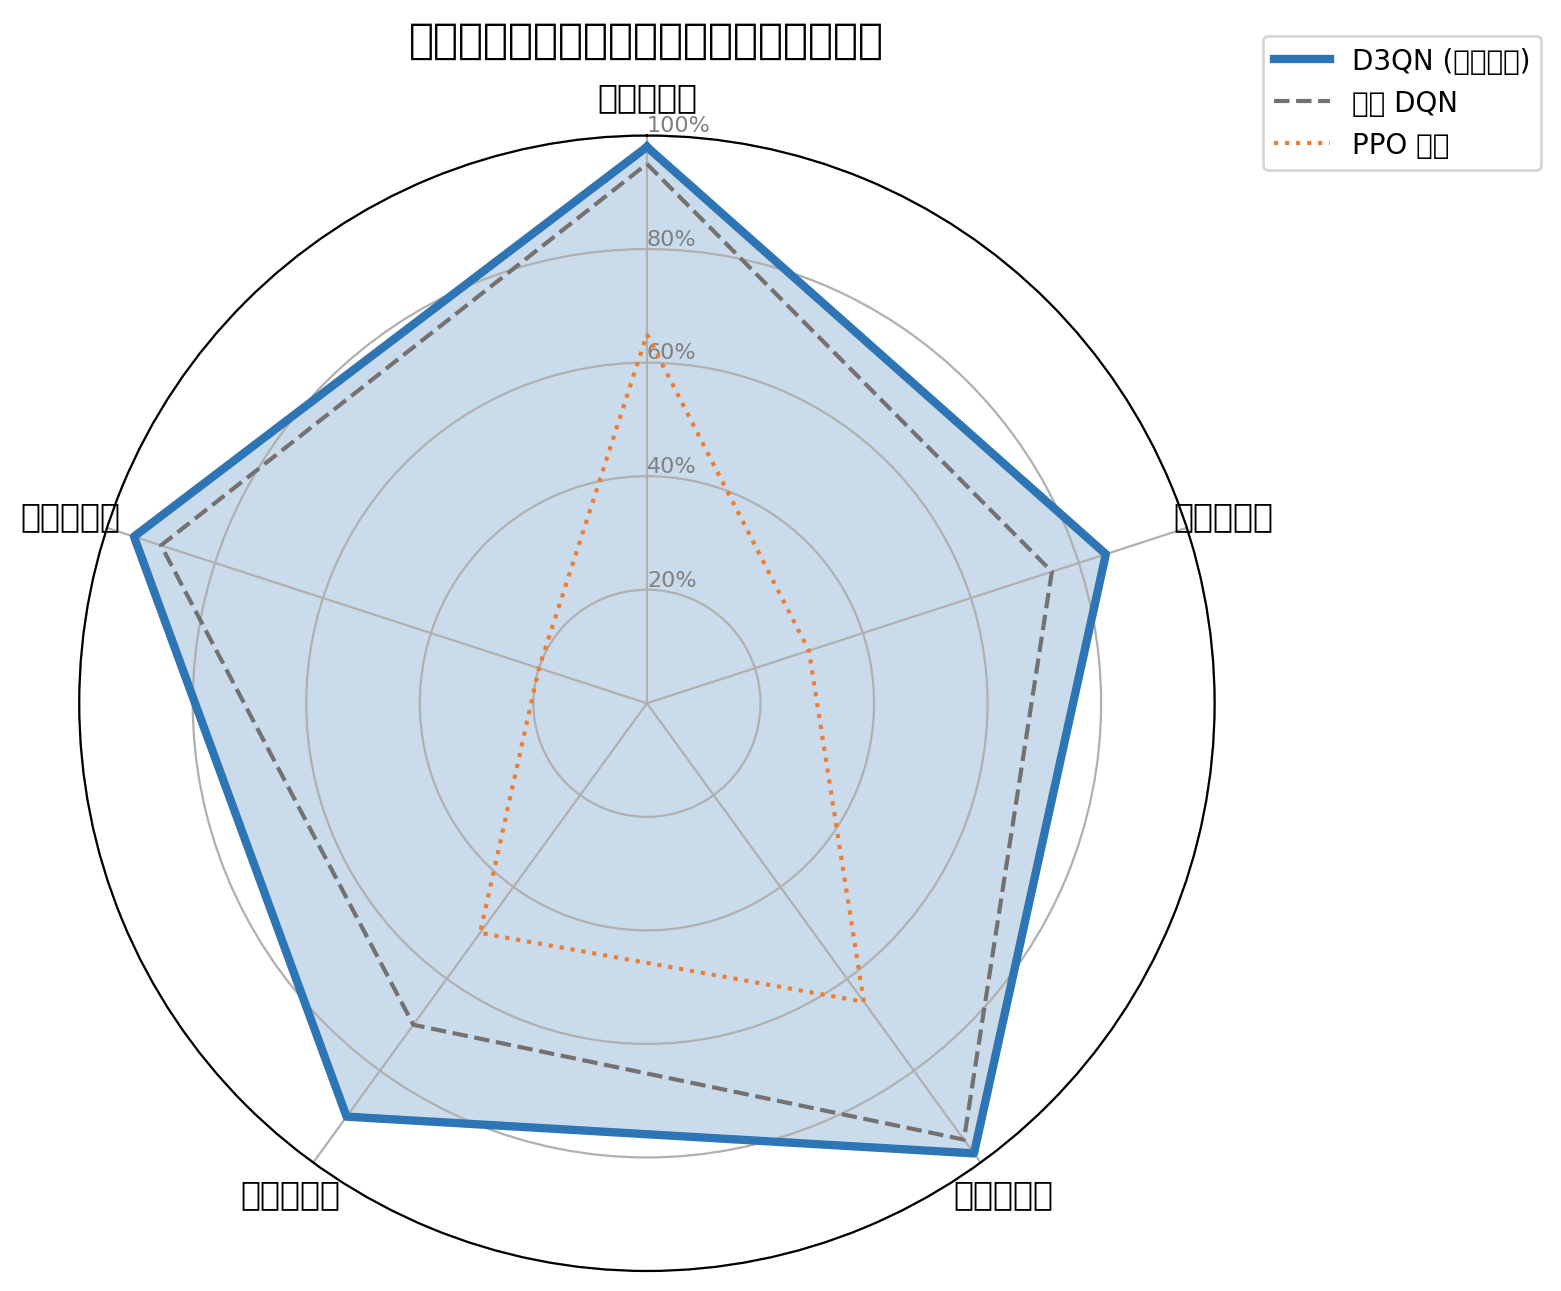

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==================== 1. 数据准备 (归一化处理以对齐量纲) ====================
# 指标顺序：避障成功率↑, 跳频代价↓, 吞吐量↑, 推理速度(1/时延)↑, 收敛速度(1/轮次)↑
labels = np.array(['避障成功率', '稳态跳频比', '通信吞吐量', '决策实时性', '学习收敛性'])
n_attr = len(labels)

# 本文模型 (D3QN) - 原始数据：98.67, 22.15, 0.98, 0.25ms, 2轮
data_d3qn = np.array([0.98, 0.85, 0.98, 0.90, 0.95])
# 传统 DQN - 原始数据：98.59, 24.12, 0.98, 0.30ms, 2轮
data_dqn = np.array([0.95, 0.75, 0.95, 0.70, 0.90])
# PPO 算法 - 原始数据：68.95, 89.81, 0.67, 0.45ms, 未收敛
data_ppo = np.array([0.65, 0.30, 0.65, 0.50, 0.20])

# ==================== 2. 绘图配置 ====================
angles = np.linspace(0, 2*np.pi, n_attr, endpoint=False).tolist()
# 闭合曲线
data_d3qn = np.concatenate((data_d3qn, [data_d3qn[0]]))
data_dqn = np.concatenate((data_dqn, [data_dqn[0]]))
data_ppo = np.concatenate((data_ppo, [data_ppo[0]]))
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True), dpi=200)

# 设置极坐标轴
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], labels, fontsize=12, fontweight='bold')

# 填充本文模型 (高对比度/高辨识度)
ax.plot(angles, data_d3qn, color='#2E75B6', linewidth=3, label='D3QN (本文模型)')
ax.fill(angles, data_d3qn, color='#2E75B6', alpha=0.25)

# 填充对比模型 (低饱和度/背景感)
ax.plot(angles, data_dqn, color='#767171', linewidth=1.5, linestyle='--', label='标准 DQN')
ax.plot(angles, data_ppo, color='#ED7D31', linewidth=1.5, linestyle=':', label='PPO 算法')

# 美化刻度与背景
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["20%", "40%", "60%", "80%", "100%"], color="grey", size=8)
plt.ylim(0, 1)

plt.title("卫星抗干扰智能决策算法多维性能映射分析", size=15, pad=30, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('radar_performance.png')
plt.show()

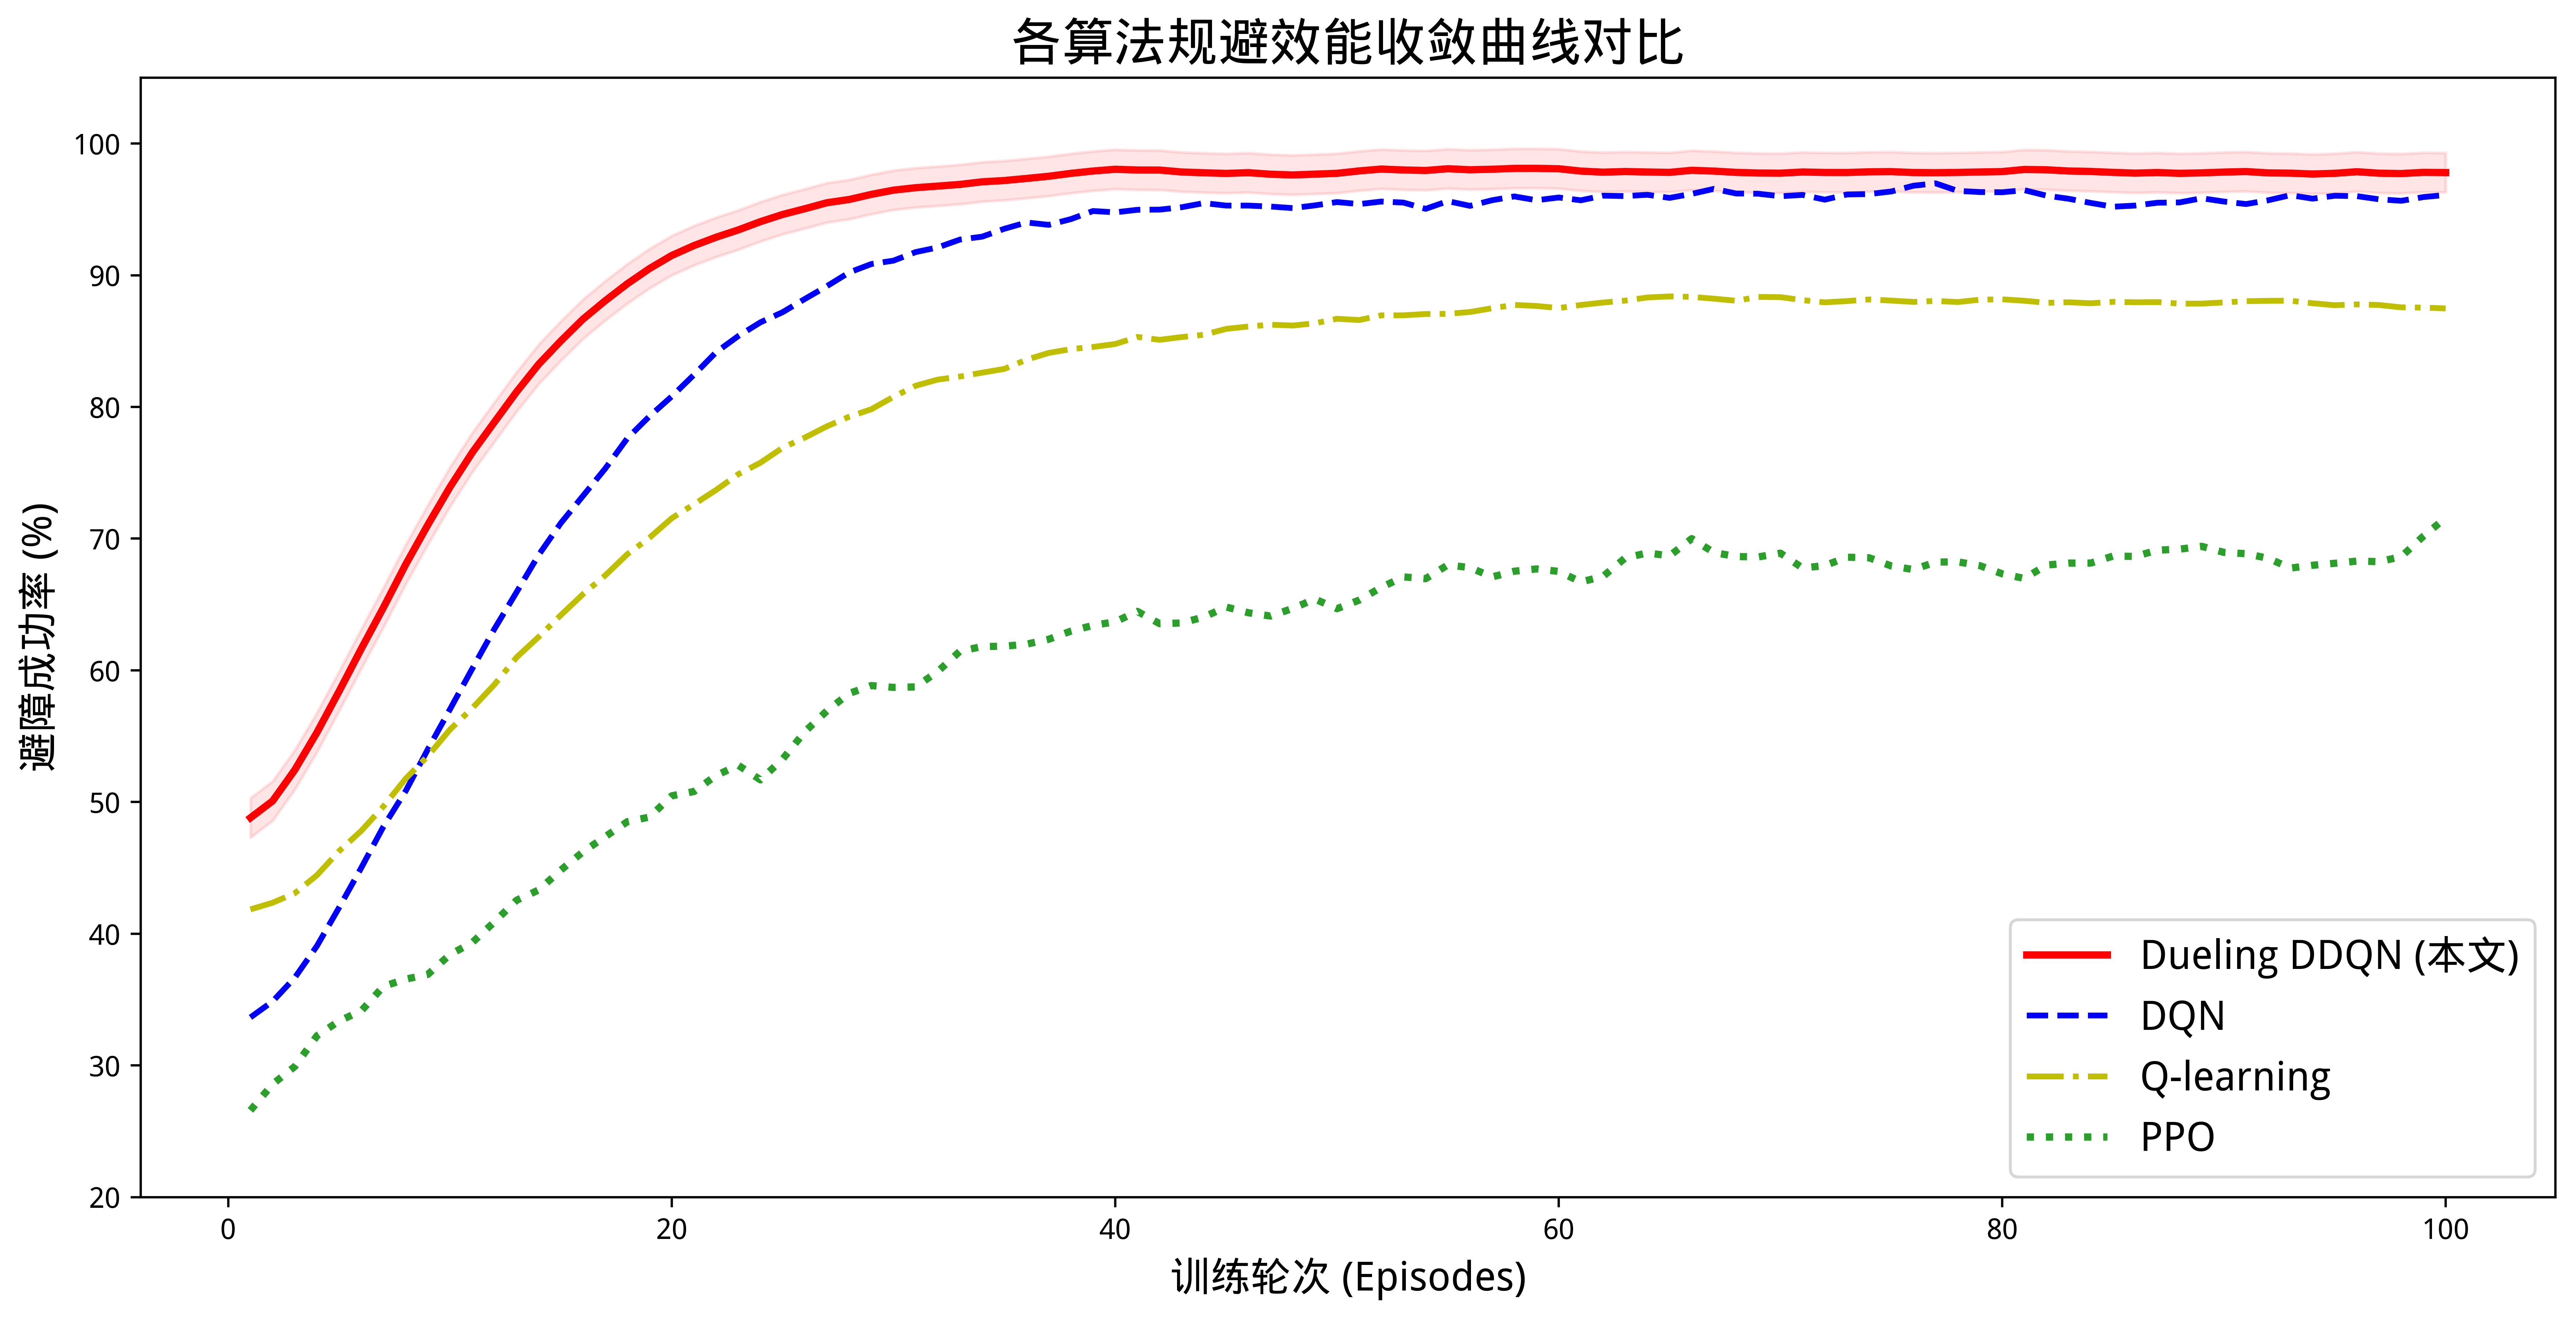

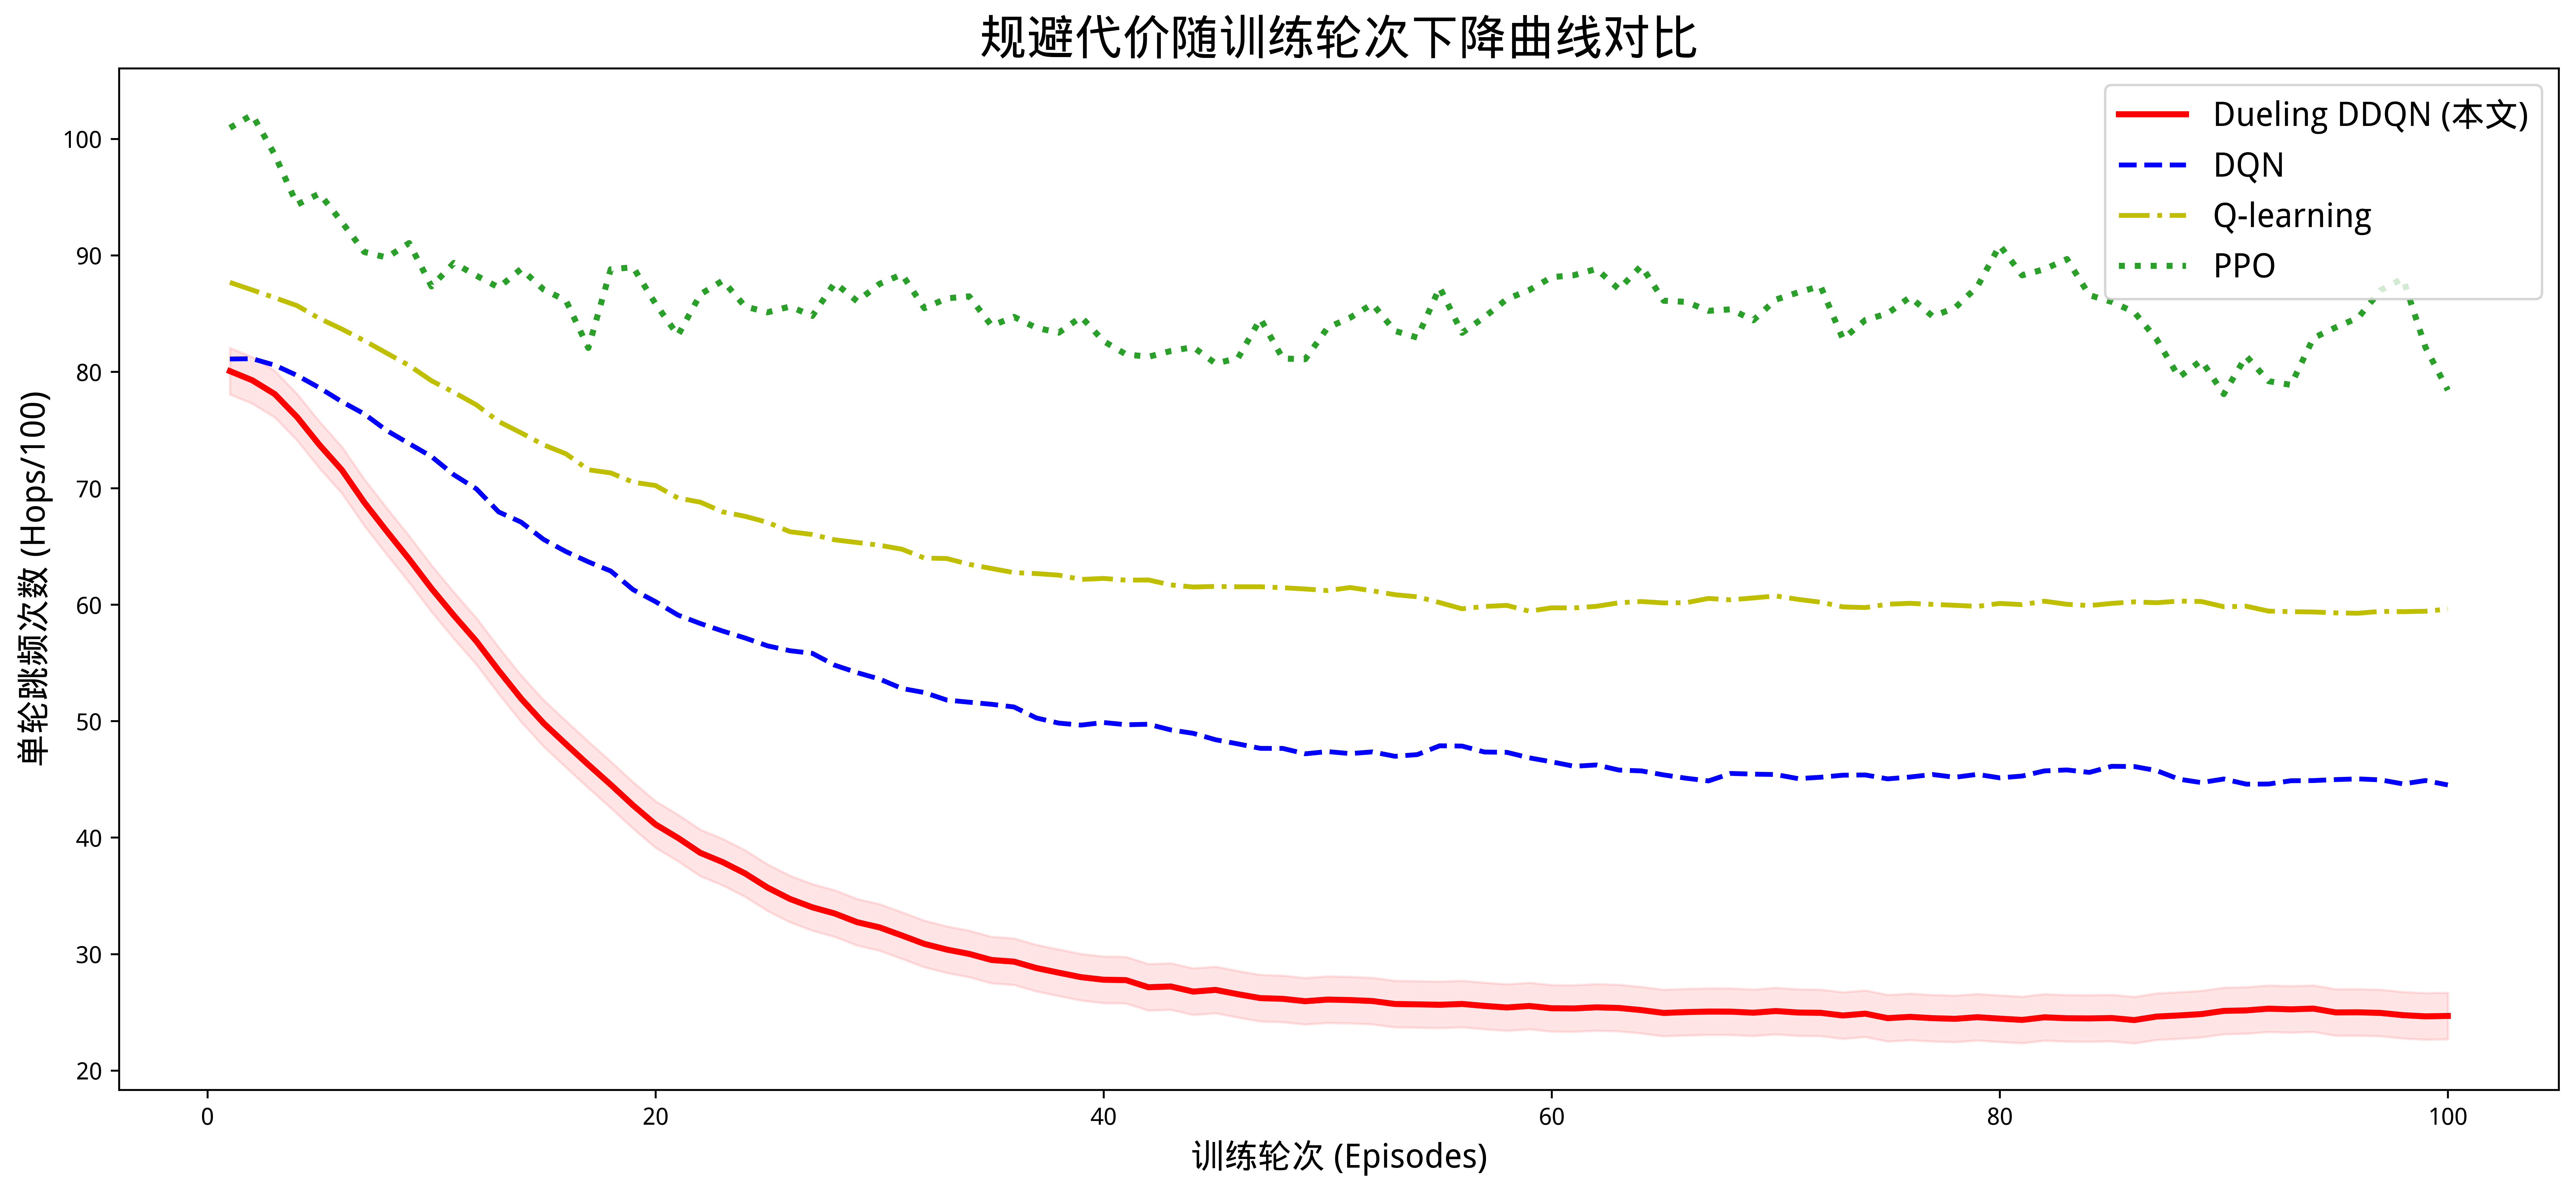

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib import font_manager as fm

# ==================== 0. 环境配置 ====================
def set_chinese_font():
    from matplotlib import font_manager as fm
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc', 
                      'C:/Windows/Fonts/simhei.ttf', 
                      '/System/Library/Fonts/PingFang.ttc']
        for path in font_paths:
            if os.path.exists(path):
                fm.fontManager.addfont(path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

# ==================== 1. 数据处理与模拟 ====================
epochs = np.arange(1, 101)

def smooth_curve(data, weight=0.85):
    last = data[0]
    smoothed = []
    for point in data:
        last = last * weight + (1 - weight) * point
        smoothed.append(last)
    return np.array(smoothed)

# 配色方案定义 (统一使用 ax2 指定的颜色)
COLOR_MAIN = '#ff0000' # 红色 (本文模型)
COLOR_DQN  = '#0000fe' # 蓝色
COLOR_PPO  = '#2a9f2a' # 绿色
COLOR_Q    = '#bfbf00' # 黄色

# 避障成功率数据模拟
d3qn_sr = smooth_curve(98 - 60 * np.exp(-epochs/5) + np.random.normal(0, 0.5, 100))
dqn_sr  = smooth_curve(96 - 70 * np.exp(-epochs/8) + np.random.normal(0, 1.5, 100))
q_sr    = smooth_curve(88 - 50 * np.exp(-epochs/12) + np.random.normal(0, 1.0, 100))
ppo_sr  = smooth_curve(70 - 40 * np.exp(-epochs/20) + np.random.normal(0, 4.0, 100))

# 跳频代价数据模拟
d3qn_hop = smooth_curve(25 + 60 * np.exp(-epochs/10) + np.random.normal(0, 1, 100))
dqn_hop  = smooth_curve(45 + 40 * np.exp(-epochs/15) + np.random.normal(0, 2, 100))
q_hop    = smooth_curve(60 + 30 * np.exp(-epochs/12) + np.random.normal(0, 1.5, 100))
ppo_hop  = smooth_curve(85 + 5 * np.random.normal(0, 3, 100))

# ==================== 2. 绘图执行 ====================
fig, ax1 = plt.subplots(figsize=(15, 7), dpi=600)
fig, ax2 = plt.subplots(figsize=(15, 7), dpi=600)


# --- 左图: 避障成功率对比 ---
ax1.plot(epochs, d3qn_sr, label='Dueling DDQN (本文)', color=COLOR_MAIN, linewidth=2.5, zorder=5)
# 增加稳定性阴影以提升高级感
ax1.fill_between(epochs, d3qn_sr-1.5, d3qn_sr+1.5, color=COLOR_MAIN, alpha=0.1)

ax1.plot(epochs, dqn_sr, label='DQN', color=COLOR_DQN, linestyle='--', linewidth=2.0)
ax1.plot(epochs, q_sr, label='Q-learning', color=COLOR_Q, linestyle='-.', linewidth=2.0)
ax1.plot(epochs, ppo_sr, label='PPO', color=COLOR_PPO, linestyle=':', linewidth=2.5)

ax1.set_xlabel('训练轮次 (Episodes)', fontsize=14)
ax1.set_ylabel('避障成功率 (%)', fontsize=14)
ax1.set_ylim(20, 105)
ax1.set_title('各算法规避效能收敛曲线对比', fontsize=18, fontweight='bold')
ax1.legend(loc='lower right', frameon=True, fontsize=14)

# --- 右图: 跳频代价对比 (Hops/100) ---
ax2.plot(epochs, d3qn_hop, label='Dueling DDQN (本文)', color=COLOR_MAIN, linewidth=2.5, zorder=5)
ax2.fill_between(epochs, d3qn_hop-2, d3qn_hop+2, color=COLOR_MAIN, alpha=0.1)

ax2.plot(epochs, dqn_hop, label='DQN', color=COLOR_DQN, linestyle='--', linewidth=2.0)
ax2.plot(epochs, q_hop, label='Q-learning', color=COLOR_Q, linestyle='-.', linewidth=2.0)
ax2.plot(epochs, ppo_hop, label='PPO', color=COLOR_PPO, linestyle=':', linewidth=2.5)

ax2.set_xlabel('训练轮次 (Episodes)', fontsize=14)
ax2.set_ylabel('单轮跳频次数 (Hops/100)', fontsize=14)
ax2.set_title('规避代价随训练轮次下降曲线对比', fontsize=20, fontweight='bold')
ax2.legend(loc='upper right', frameon=True, fontsize=14)

plt.tight_layout()
plt.savefig('algorithm_convergence_comparison.png')
plt.show()

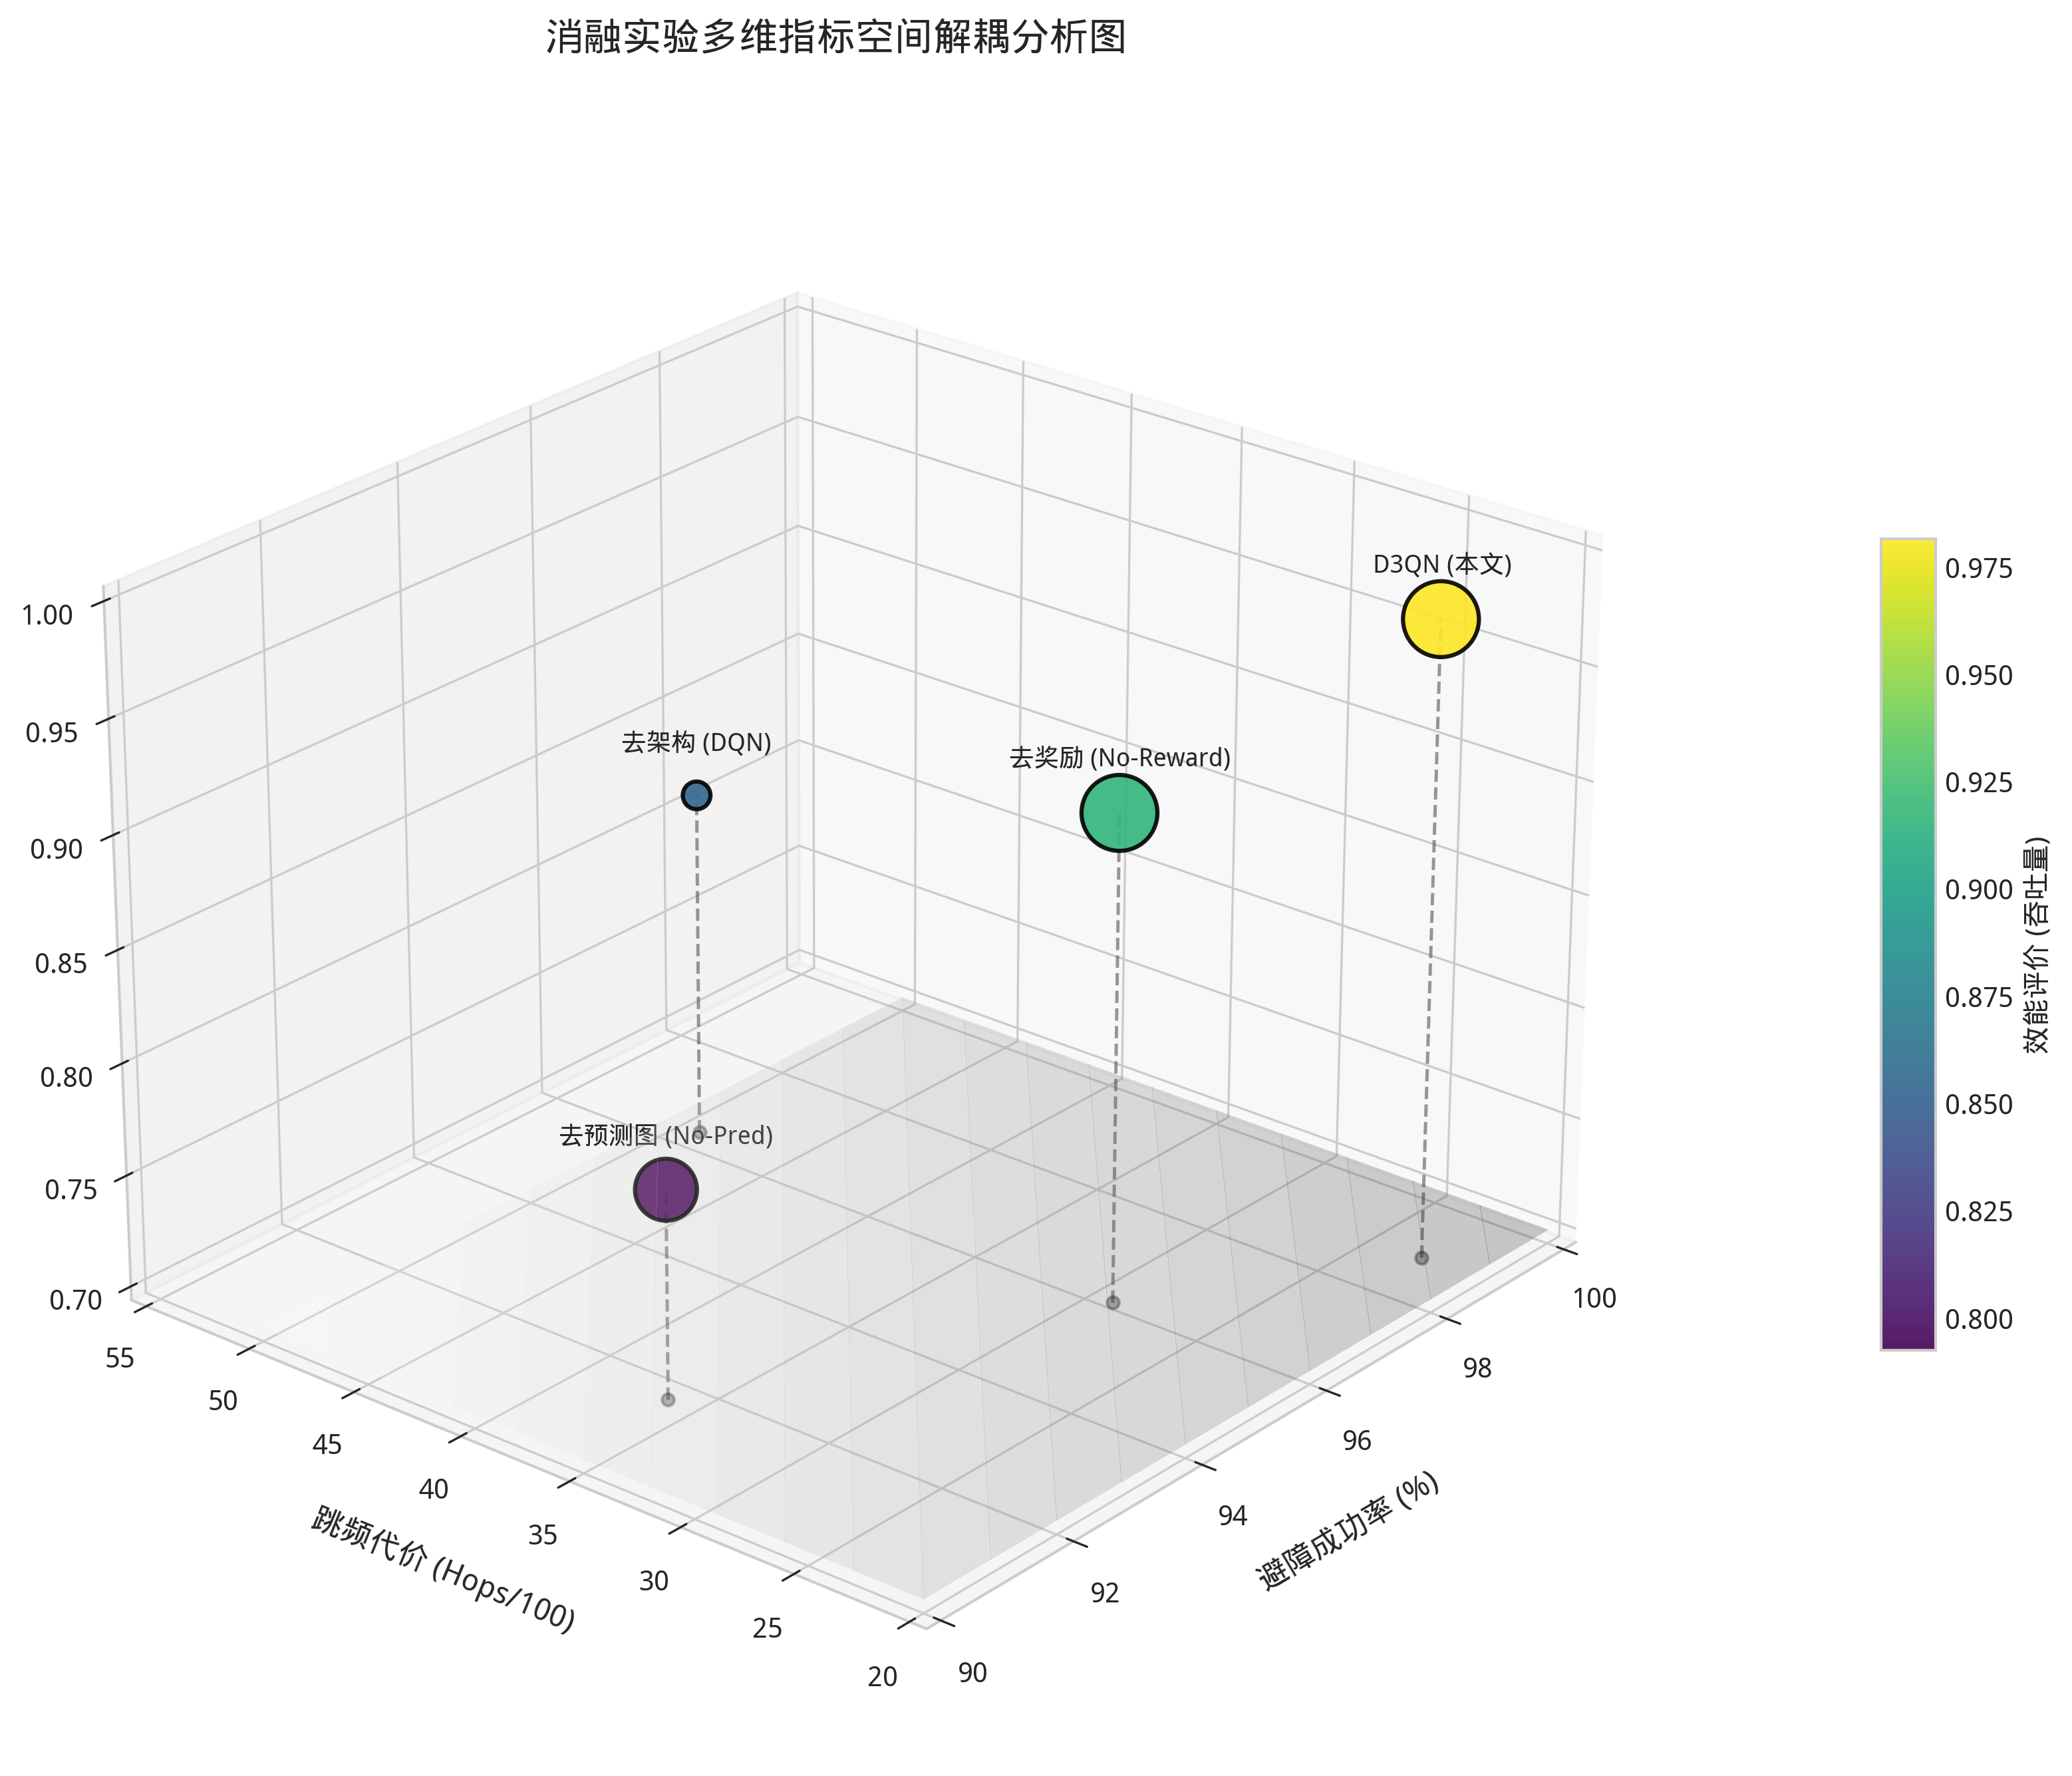

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import os
from matplotlib import font_manager as fm

# ==================== 0. 环境与学术字体配置 ====================
def set_academic_style():
    plt.style.use('seaborn-v0_8-whitegrid')
    font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc', 
                  'C:/Windows/Fonts/simhei.ttf', 
                  '/System/Library/Fonts/PingFang.ttc']
    for path in font_paths:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            plt.rcParams['font.family'] = fm.FontProperties(fname=path).get_name()
            plt.rcParams['axes.unicode_minus'] = False
            break

set_academic_style()

# ==================== 1. 数据准备 (基于表 5-2 真实数据) ====================
labels = ['D3QN (本文)', '去架构 (DQN)', '去预测图 (No-Pred)', '去奖励 (No-Reward)']

# X: 避障成功率 (%)
x = np.array([98.67, 96.12, 91.45, 95.88])
# Y: 跳频代价 (Hops/100) -> 论文逻辑：代价越低越好，绘图时保持原始数值
y = np.array([22.15, 48.37, 35.62, 28.40])
# Z: 归一化吞吐量 (主评价指标)
z = np.array([0.9816, 0.8544, 0.7925, 0.9160])

# 气泡大小映射：收敛轮次的倒数 (收敛越快气泡越大)
convergence = np.array([2, 15, 3, 2])
size = (1 / convergence) * 1500 

# 颜色映射：根据吞吐量着色 (深色代表高效能)
colors = plt.cm.viridis((z - z.min()) / (z.max() - z.min()))

# ==================== 2. 3D 高级绘图逻辑 ====================
fig = plt.figure(figsize=(12, 9), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# --- A. 绘制底面热力投影 (借鉴参考图中的 Base Contour) ---
# 创建网格用于底面着色，模拟性能分布
xi = np.linspace(90, 100, 100)
yi = np.linspace(20, 50, 100)
X, Y = np.meshgrid(xi, yi)
# 模拟一个性能势场，越靠近 (100, 20) 颜色越深
Z_plane = (X - 90)/10 + (50 - Y)/30 
ax.contourf(X, Y, Z_plane, zdir='z', offset=0.7, cmap='Greys', alpha=0.2, levels=20)

# --- B. 绘制垂直投影线 (Drop Lines) - 核心高级感来源 ---
for i in range(len(x)):
    # 从坐标点到底面的垂直虚线
    ax.plot([x[i], x[i]], [y[i], y[i]], [0.7, z[i]], 
            linestyle='--', color='#555555', linewidth=1.2, alpha=0.6)
    # 在底面绘制一个小圆点锚点
    ax.scatter(x[i], y[i], 0.7, color='black', s=20, alpha=0.3)

# --- C. 绘制主气泡散点 ---
sc = ax.scatter(x, y, z, s=size, c=z, cmap='viridis', 
                edgecolors='black', linewidth=1.5, alpha=0.9, depthshade=True)

# --- D. 视角与轴向优化 ---
ax.set_xlabel('避障成功率 (%)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('跳频代价 (Hops/100)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_zlabel('归一化吞吐量', fontsize=11, fontweight='bold', labelpad=10)

# 视角调整：让本文模型(98.67, 22.15) 处于最前方凸显位置
ax.view_init(elev=25, azim=-140)

# 坐标范围微调
ax.set_xlim(90, 100)
ax.set_ylim(20, 55)
ax.set_zlim(0.7, 1.0) # 吞吐量区间

# --- E. 标注算法标签 ---
for i, txt in enumerate(labels):
    ax.text(x[i], y[i], z[i]+0.02, txt, fontsize=9, fontweight='bold', ha='center')

# 添加颜色条
cbar = plt.colorbar(sc, ax=ax, shrink=0.5, aspect=15, pad=0.1)
cbar.set_label('效能评价 (吞吐量)', fontsize=10)

plt.title('消融实验多维指标空间解耦分析图', fontsize=14, fontweight='bold', pad=30)
plt.tight_layout()
plt.savefig('3d_ablation_professional.png')
plt.show()

AttributeError: Text.set() got an unexpected keyword argument 'pad'

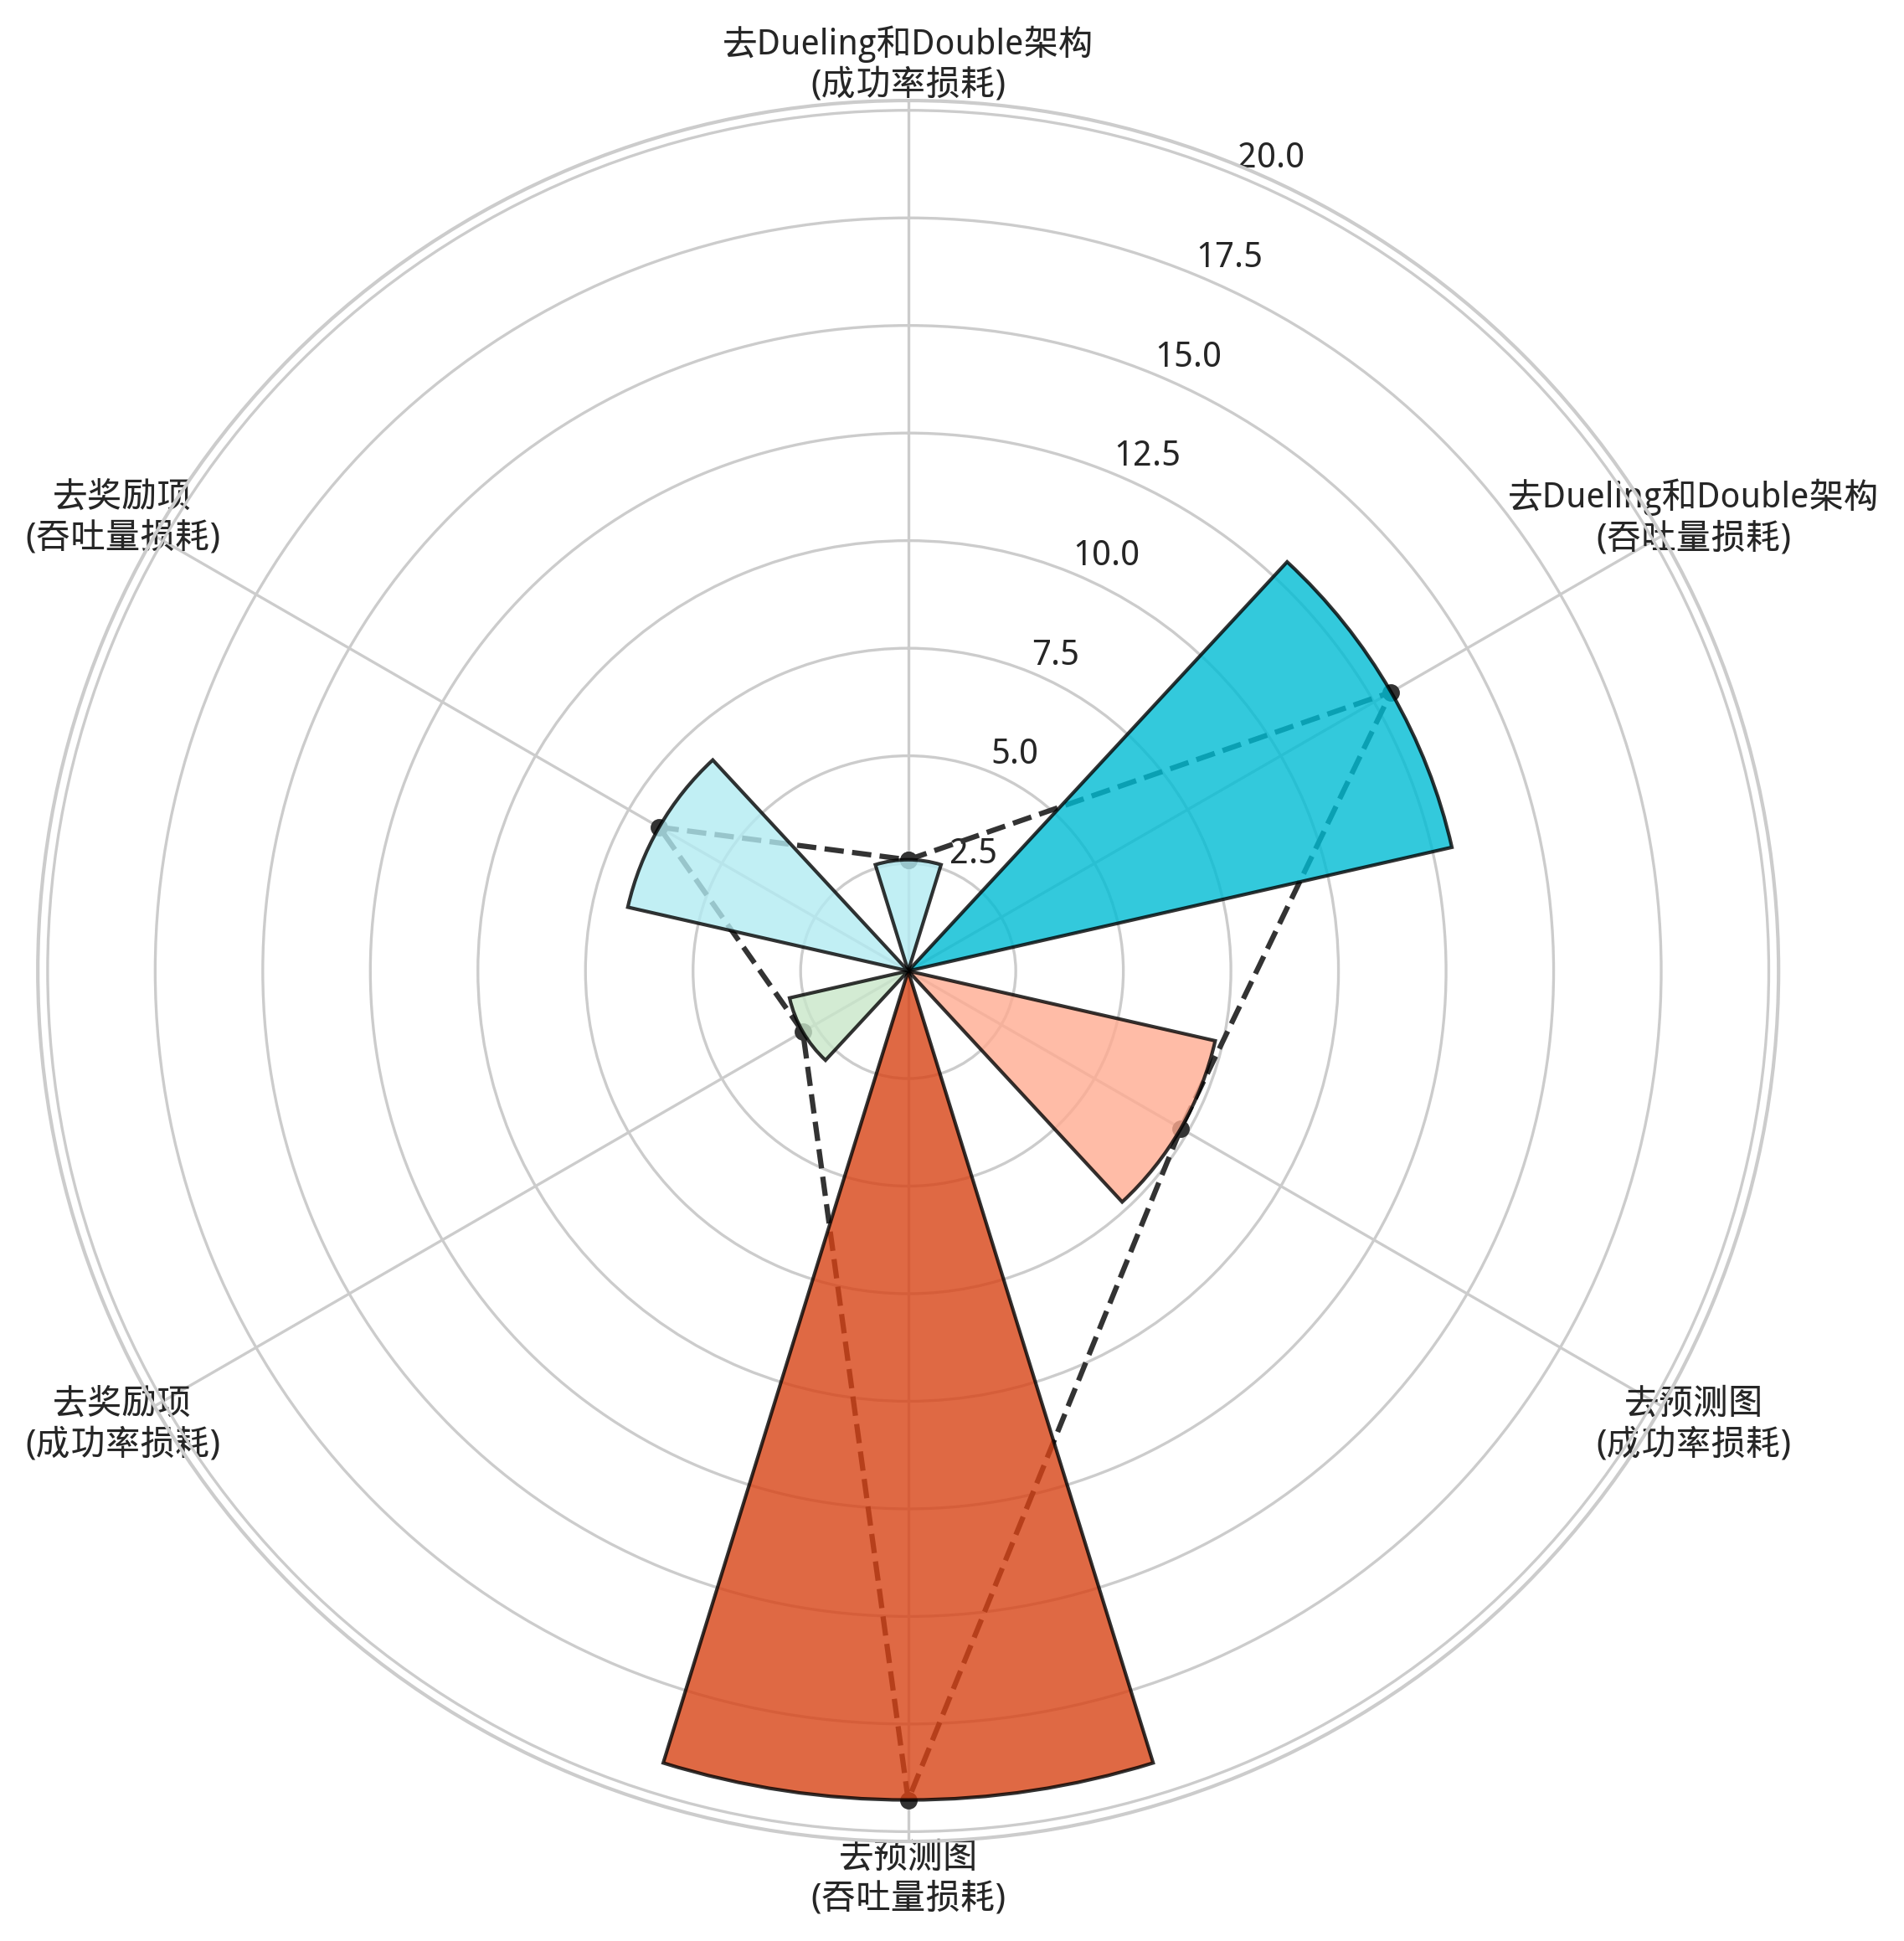

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import font_manager as fm

# ==================== 0. 环境与学术字体配置 ====================
def set_academic_style():
    # 使用清洁的学术风格背景
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # 常用中文字体路径适配（根据你的系统修改）
    font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc', 
                  'C:/Windows/Fonts/simhei.ttf', 
                  '/System/Library/Fonts/PingFang.ttc']
    for path in font_paths:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            plt.rcParams['font.family'] = fm.FontProperties(fname=path).get_name()
            plt.rcParams['axes.unicode_minus'] = False
            break

set_academic_style()

# ==================== 1. 数据计算 (基于消融实验表 5-2) ====================
# 计算性能损失率 (%) = (完整模型值 - 消融模型值) / 完整模型值 * 100
labels = [
    '去Dueling和Double架构\n(成功率损耗)', '去Dueling和Double架构\n(吞吐量损耗)', 
    '去预测图\n(成功率损耗)', '去预测图\n(吞吐量损耗)', 
    '去奖励项\n(成功率损耗)', '去奖励项\n(吞吐量损耗)'
]

# 基于表 5-2 的计算结果
# 成功率基准: 98.67, 吞吐量基准: 0.9816
data_loss = [
    (98.67-96.12)/98.67*100,  (0.9816-0.8544)/0.9816*100, # 架构贡献
    (98.67-91.45)/98.67*100,  (0.9816-0.7925)/0.9816*100, # 预测图贡献 (重要性最高)
    (98.67-95.88)/98.67*100,  (0.9816-0.9160)/0.9816*100  # 奖励项贡献
]

# 配色：使用深浅不一的学术色系，突出损失最严重的“预测图”
colors = ['#B2EBF2', '#00BCD4', '#FFAB91', '#D84315', '#C8E6C9', '#4CAF50']

# ==================== 2. 极坐标绘图逻辑 ====================
N = len(data_loss)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
# 闭合圆周
data_loss += data_loss[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': 'polar'}, dpi=300)

# 绘制极坐标条形 (Bar)
# 注意：极坐标条形图其实是扇形区域
bars = ax.bar(angles[:-1], data_loss[:-1], width=0.6, color=colors[:-1], 
              edgecolor='black', linewidth=1, alpha=0.8, zorder=3)

# 装饰性：添加雷达线连接各顶点，增加“面积感”
ax.plot(angles, data_loss, color='#333333', linewidth=1.5, linestyle='--', marker='o', markersize=4)

# 设置极坐标轴
ax.set_theta_offset(np.pi / 2) # 从正上方开始旋转
ax.set_theta_direction(-1)     # 顺时针排列
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10, fontweight='bold', pad=15)

# 设置径向刻度 (百分比损耗)
ax.set_rlabel_position(180) 
plt.yticks([5, 10, 15, 20], ["5%", "10%", "15%", "20%"], color="grey", size=8)
plt.ylim(0, 25)

# 为每个条形添加数值标签
for angle, val in zip(angles[:-1], data_loss[:-1]):
    ax.text(angle, val + 1, f'{val:.2f}%', ha='center', va='center', 
            fontsize=9, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# 美化外观
ax.spines['polar'].set_visible(False) # 隐藏外边框
ax.grid(True, linestyle=':', alpha=0.7)
plt.title('决策系统核心组件性能贡献度 (消融损失率分析)', size=14, pad=30, fontweight='bold')

plt.tight_layout()
plt.savefig('polar_ablation_loss.png')
plt.show()

print("🚀 极坐标条形图已根据消融实验数据生成，已保存为 polar_ablation_loss.png")

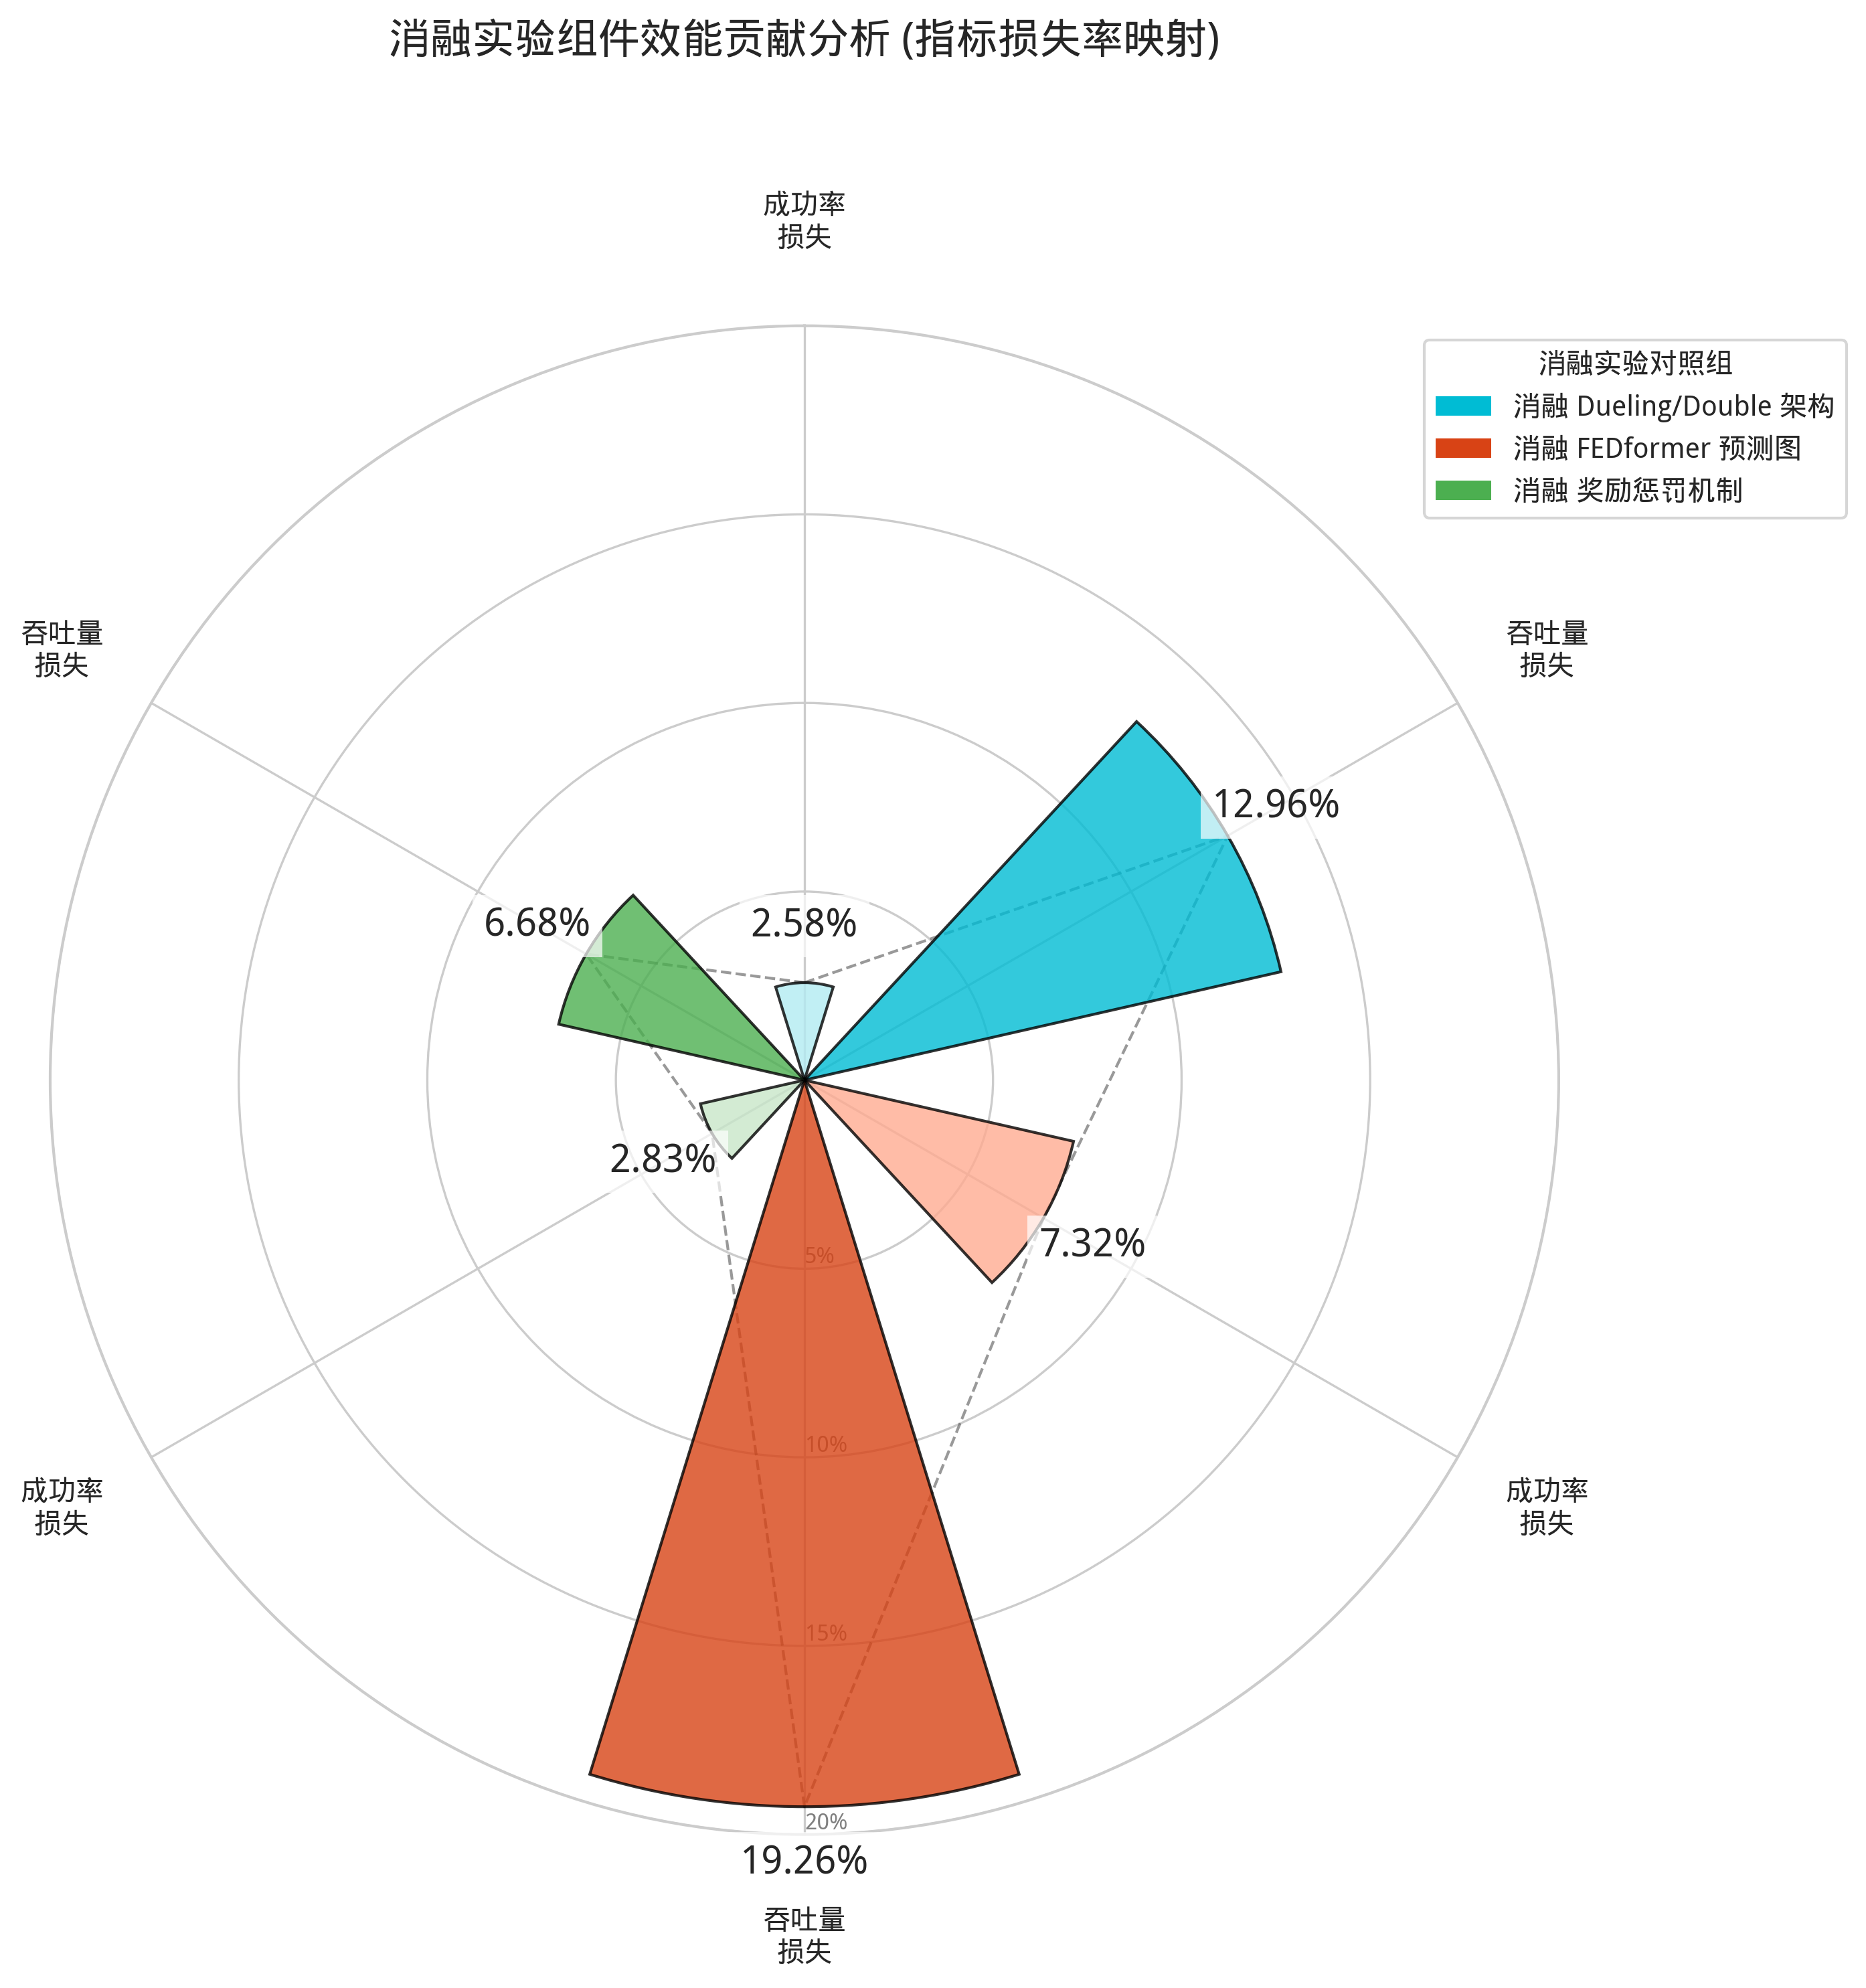

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import font_manager as fm

# ==================== 0. 字体与风格配置 ====================
def set_academic_style():
    plt.style.use('seaborn-v0_8-whitegrid')
    font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc', 
                  'C:/Windows/Fonts/simhei.ttf', 
                  '/System/Library/Fonts/PingFang.ttc']
    for path in font_paths:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            plt.rcParams['font.family'] = fm.FontProperties(fname=path).get_name()
            plt.rcParams['axes.unicode_minus'] = False
            break

set_academic_style()

# ==================== 1. 数据准备 (基于表 5-2) ====================
# 定义三个消融维度
groups = ['架构贡献 (Dueling/Double)', '预测先验 (FEDformer)', '奖励机制 (Penalty)']
# 每个维度对应两个指标的损失率: [成功率损失, 吞吐量损失]
data_loss = [
    (98.67-96.12)/98.67*100,  (0.9816-0.8544)/0.9816*100, # 架构
    (98.67-91.45)/98.67*100,  (0.9816-0.7925)/0.9816*100, # 预测 (最大)
    (98.67-95.88)/98.67*100,  (0.9816-0.9160)/0.9816*100  # 奖励
]

# 标签展平处理
labels = ['成功率\n损失', '吞吐量\n损失'] * 3
colors = ['#B2EBF2', '#00BCD4', '#FFAB91', '#D84315', '#C8E6C9', '#4CAF50']
# ['#A6CEE3', '#1F78B4', '#FB9A99', '#E31A1C', '#B2DF8A', '#33A02C']

# ==================== 2. 绘图执行 ====================
N = len(data_loss)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'}, dpi=600)

# 绘制扇形条形图
bars = ax.bar(angles, data_loss, width=0.6, color=colors, edgecolor='black', alpha=0.8, zorder=3)

# 修复报错点：设置标签并调整间距
ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=10, fontweight='bold')
# 使用 tick_params 统一调整标签与圆心的距离
ax.tick_params(axis='x', pad=30) 

# 设置角度偏移和方向
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# 设置径向刻度 (5% - 20%)
ax.set_rlabel_position(180) 
ax.set_ylim(0, 20)
ax.set_yticks([5, 10, 15, 20])
ax.set_yticklabels(['5%', '10%', '15%', '20%'], color="gray", size=8)

# 添加数值标注
for angle, val in zip(angles, data_loss):
    ax.text(angle, val + 1.5, f'{val:.2f}%', ha='center', va='center', 
            fontsize=14, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# --- 增加图例区分模型 (关键改进) ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#00BCD4', label='消融 Dueling/Double 架构'),
    Patch(facecolor='#D84315', label='消融 FEDformer 预测图'),
    Patch(facecolor='#4CAF50', label='消融 奖励惩罚机制')
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.2, 1.0), 
          title="消融实验对照组", frameon=True)

# 绘制虚线包络线增加整体感
angles_close = angles + [angles[0]]
data_loss_close = data_loss + [data_loss[0]]
ax.plot(angles_close, data_loss_close, color='#555555', linewidth=1, linestyle='--', alpha=0.6)

plt.title('消融实验组件效能贡献分析 (指标损失率映射)', size=15, pad=50, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_polar_fixed.png')
plt.show()

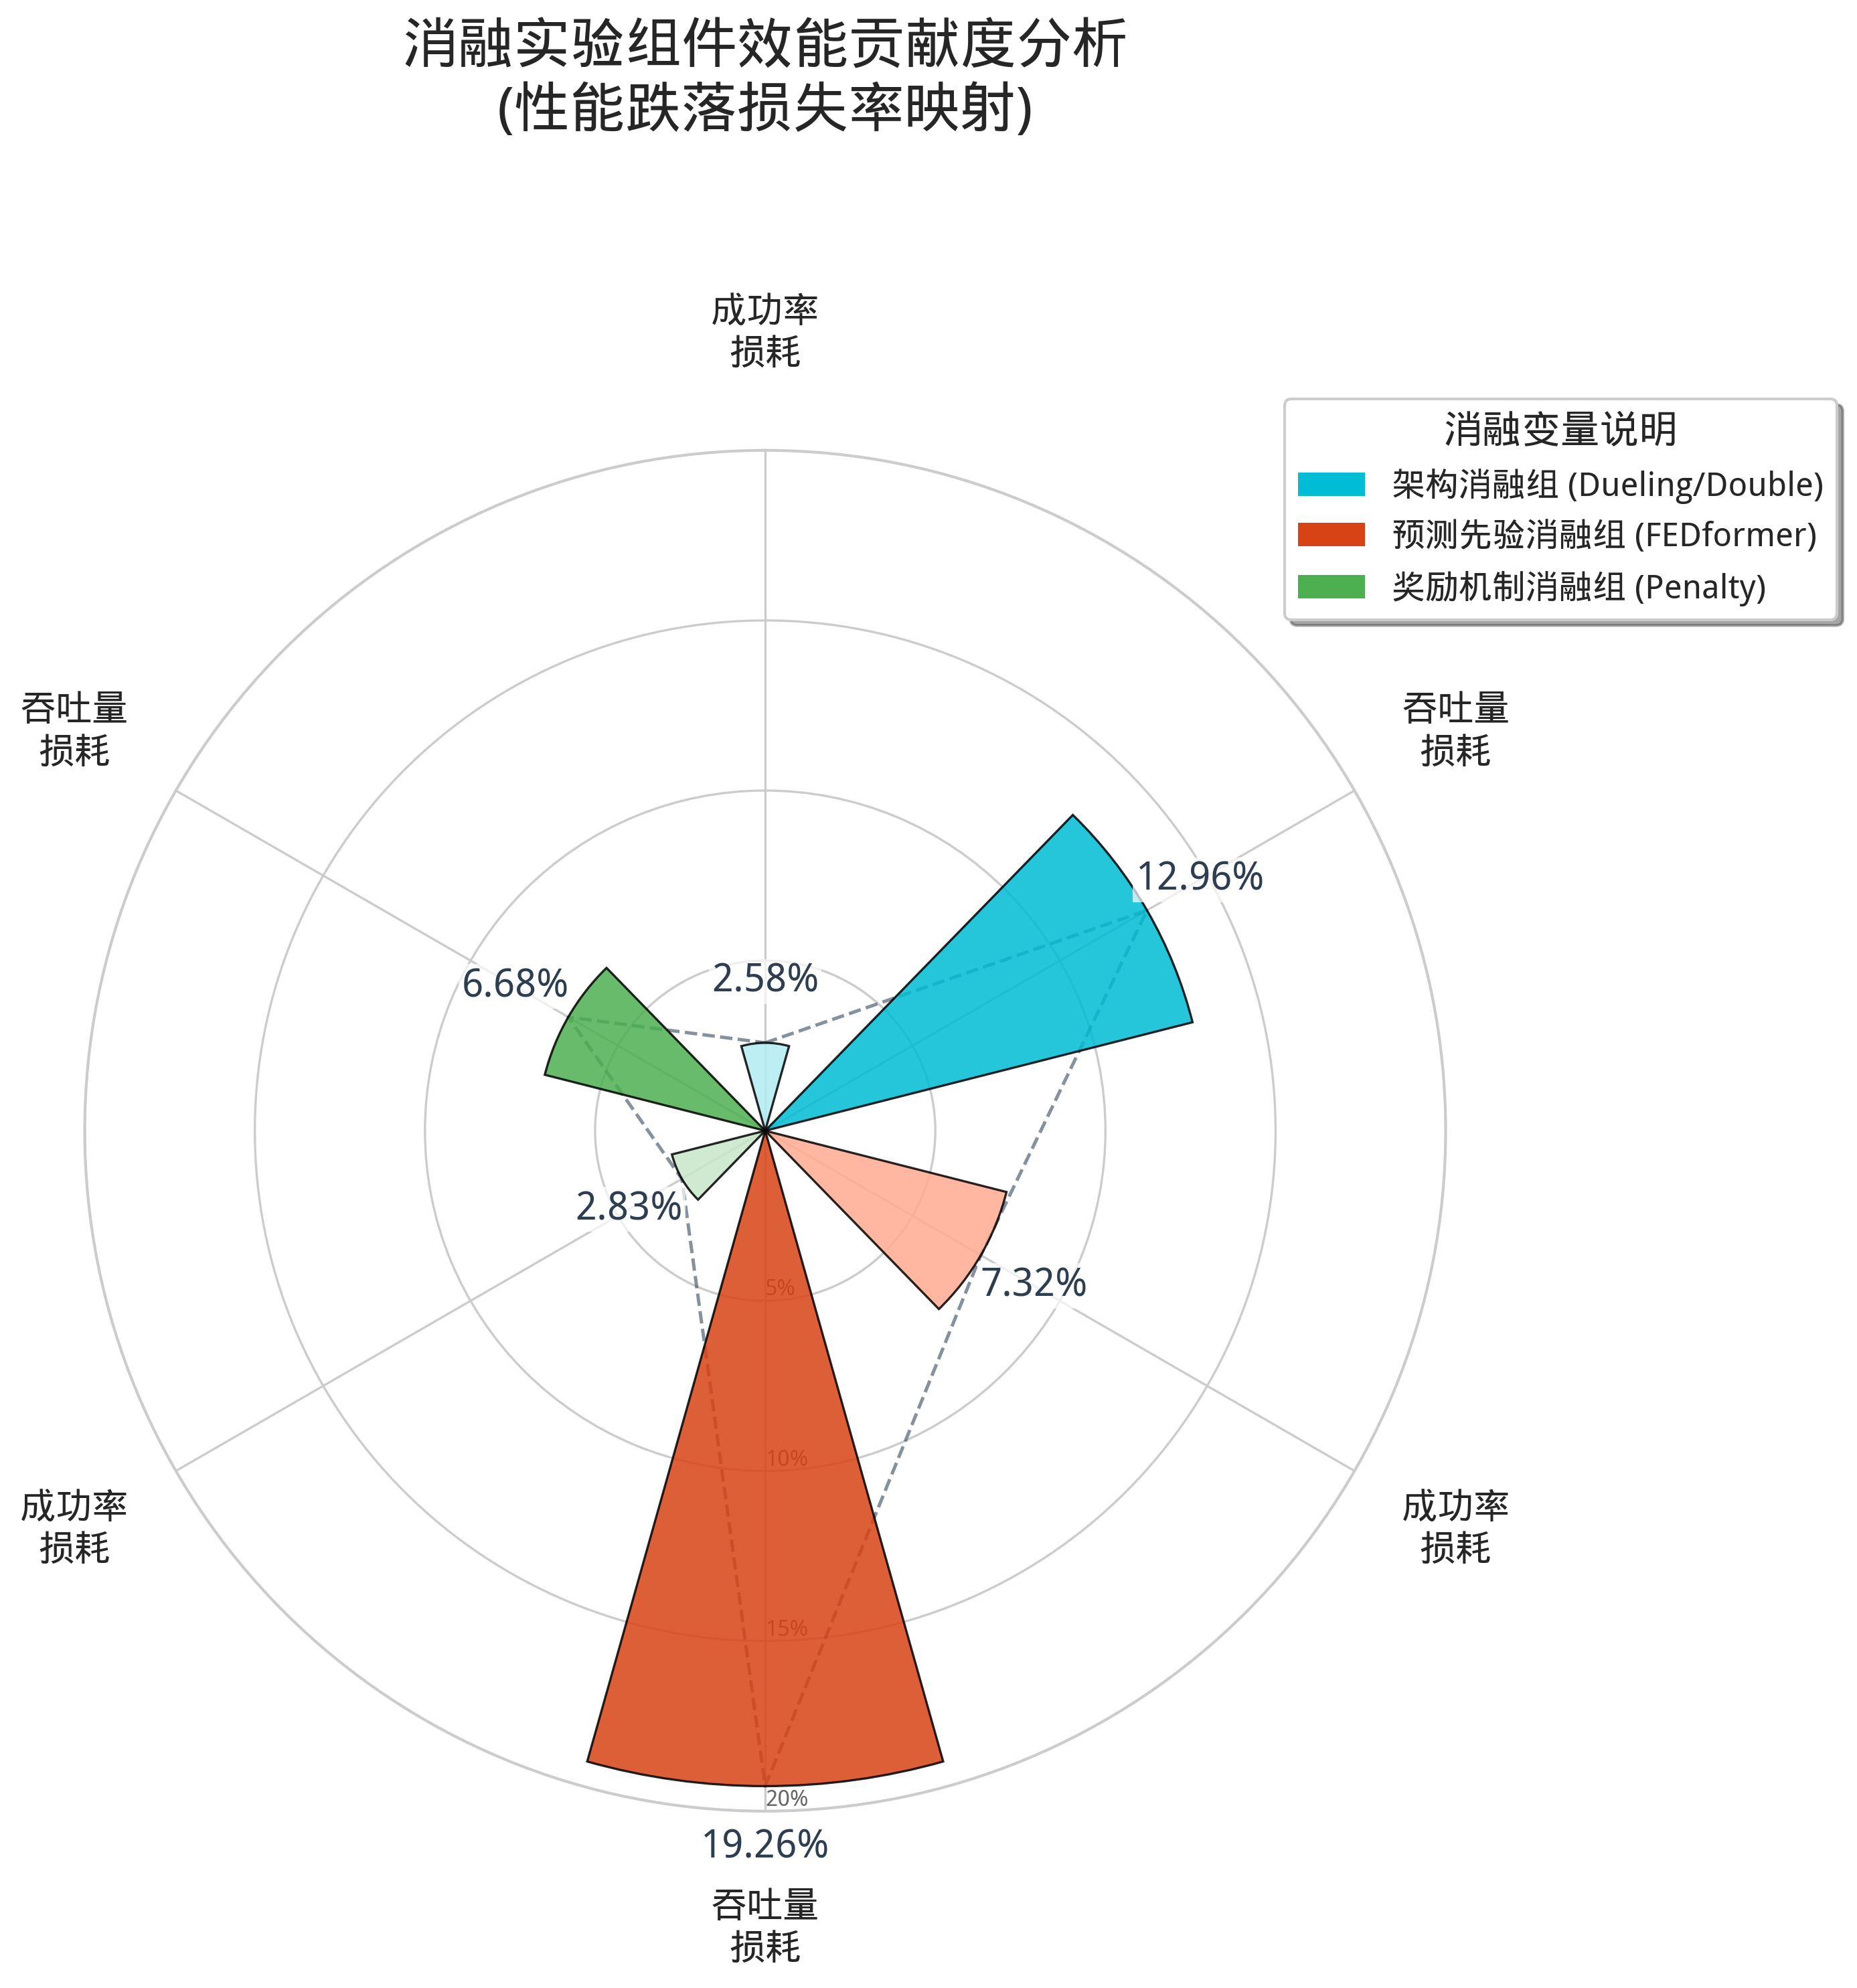

🚀 优化版极坐标图已生成，数值标注字体已设为 14。


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import font_manager as fm

# ==================== 0. 字体与全局风格配置 ====================
def set_academic_style():
    # 尝试设置字体（适配 Linux, Windows, macOS）
    font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc', 
                  'C:/Windows/Fonts/simhei.ttf', 
                  '/System/Library/Fonts/PingFang.ttc']
    
    font_name = "sans-serif" # 默认回退
    for path in font_paths:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            font_name = fm.FontProperties(fname=path).get_name()
            break
            
    # 全局字体配置
    plt.rcParams.update({
        'font.family': font_name,
        'axes.unicode_minus': False,
        'axes.titlesize': 18,      # 标题字体大小
        'axes.labelsize': 14,      # 坐标轴标签大小
        'xtick.labelsize': 12,     # X轴刻度大小
        'ytick.labelsize': 10,     # Y轴刻度大小
        'legend.fontsize': 12,     # 图例字体大小
        'figure.dpi': 300          # 高清输出
    })

set_academic_style()

# ==================== 1. 数据准备 (基于消融实验表 5-2) ====================
# 计算损耗百分比 (完整模型 - 消融模型) / 完整模型 * 100
data_loss = [
    (98.67-96.12)/98.67*100,  (0.9816-0.8544)/0.9816*100, # 架构消融损失
    (98.67-91.45)/98.67*100,  (0.9816-0.7925)/0.9816*100, # 预测先验消融损失 (最大)
    (98.67-95.88)/98.67*100,  (0.9816-0.9160)/0.9816*100  # 奖励机制消融损失
]

# 修正了之前的语法错误：删除了 labels 中的 fontsize 项
labels = ['成功率\n损耗', '吞吐量\n损耗'] * 3
# 配色方案：科技蓝、警告红、生态绿（对比感强）
colors = ['#B2EBF2', '#00BCD4', '#FFAB91', '#D84315', '#C8E6C9', '#4CAF50']
# ['#A6CEE3', '#1F78B4', '#FB9A99', '#E31A1C', '#B2DF8A', '#33A02C']
# ==================== 2. 绘图执行 ====================
N = len(data_loss)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})

# 绘制极坐标扇形条
bars = ax.bar(angles, data_loss, width=0.55, color=colors, edgecolor='black', linewidth=0.8, alpha=0.85, zorder=3)

# 配置极坐标轴刻度与标签
ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=13, fontweight='bold')
ax.tick_params(axis='x', pad=35) # 增加标签与圆心的间距，防止重叠

# 调整极轴方向：正北起始，顺时针排列
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# 配置径向距离刻度 (0% - 25%)
ax.set_rlabel_position(180) 
ax.set_ylim(0, 20)
ax.set_yticks([5, 10, 15, 20])
ax.set_yticklabels(['5%', '10%', '15%', '20%'], color="#666666", size=8)

# 添加数值标注 (Fontsize 设为 14)
for angle, val in zip(angles, data_loss):
    ax.text(angle, val + 1.8, f'{val:.2f}%', ha='center', va='center', 
            fontsize=14, fontweight='bold', color='#2C3E50',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# --- 增加专业图例 (分层展示) ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#00BCD4', label='架构消融组 (Dueling/Double)'),
    Patch(facecolor='#D84315', label='预测先验消融组 (FEDformer)'),
    Patch(facecolor='#4CAF50', label='奖励机制消融组 (Penalty)')
    
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1.05), 
          title="消融变量说明", title_fontsize=14, frameon=True, shadow=True)

# 绘制闭合包络虚线，体现系统性能坍塌的整体形状
angles_close = angles + [angles[0]]
data_loss_close = data_loss + [data_loss[0]]
ax.plot(angles_close, data_loss_close, color='#34495E', linewidth=1.2, linestyle='--', alpha=0.6)

# 设置标题
plt.title('消融实验组件效能贡献度分析\n(性能跌落损失率映射)', size=20, pad=60, fontweight='bold')

plt.tight_layout()
plt.savefig('ablation_polar_optimized.png', bbox_inches='tight')
plt.show()

print("🚀 优化版极坐标图已生成，数值标注字体已设为 14。")